Dumbbell Surface: Mixed Basis (Static) -> Global Poly (Dynamic)
Stage 1: deg≤3 polynomials + 150 Wendland C2
Stage 2: deg≤3, 19 global polynomials
Particles: 1000
Initial density std/mean: 0.352132
Generated 150 uniform centers for Stage 1
Stage 1: Static Uniformization (Mixed Basis: Polynomials + Wendland)
Polynomial: deg≤3, 19 functions
Local: 150 Wendland C2, epsilon=0.5
Total: 169 basis functions
Uniform reference values computed (weighted area method)
  Step 0: density std/mean = 0.340025, b_max = 5.108249e-02, active basis = 169/169, v_max = 0.7242
  Step 50: density std/mean = 0.053546, b_max = 5.200624e-05, active basis = 169/169, v_max = 0.0005
  Step 100: density std/mean = 0.053859, b_max = 1.538169e-08, active basis = 169/169, v_max = 0.0000
  Step 150: density std/mean = 0.053859, b_max = 4.548861e-12, active basis = 169/169, v_max = 0.0000

Verification: Polynomial residual using Stage 1 vs Stage 2 references
Using Stage 1 reference: poly residual max = 8.881784e-16
Using

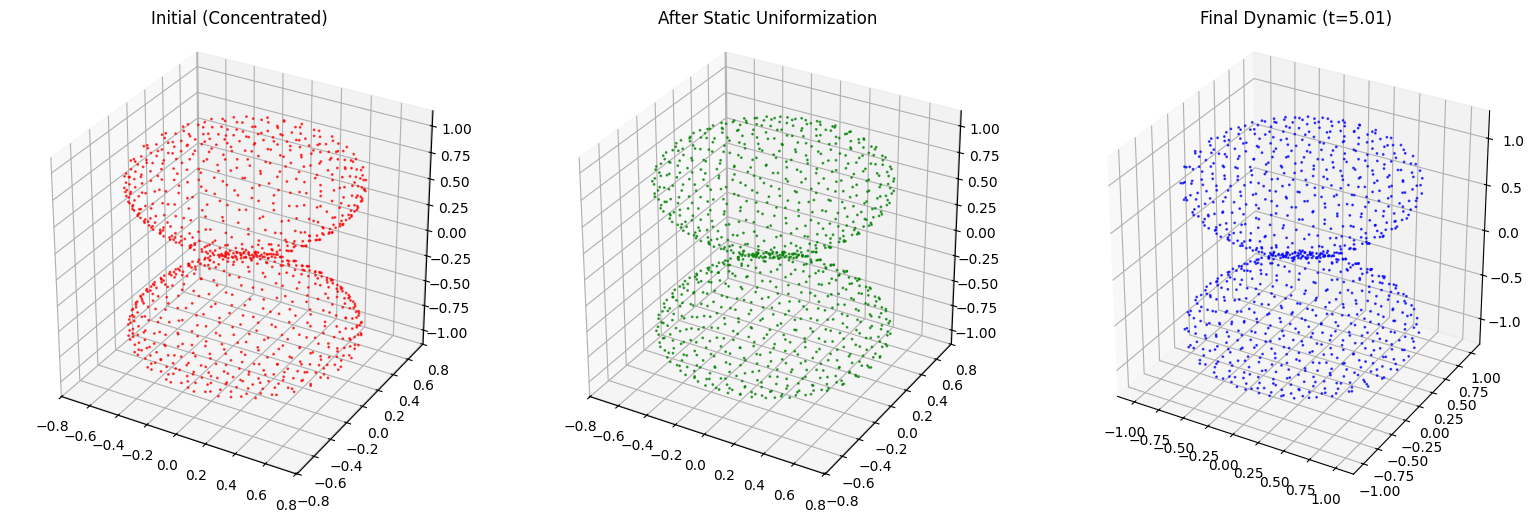

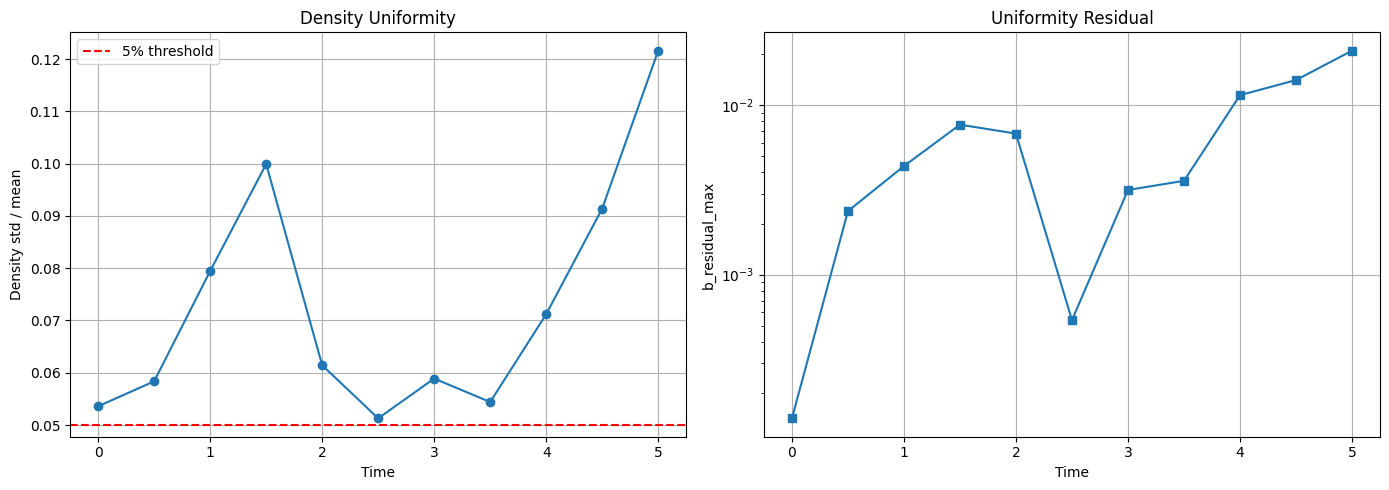


Final density std/mean: 0.121598


In [12]:
import numpy as np
from scipy.linalg import lstsq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================================
# 0. 全局参数
# ============================================================
N = 1000
MAX_DEG_LOCAL = 3      # 阶段1局部基函数中的多项式次数
N_LOCAL = 150
EPSILON = 0.5
MAX_DEG_GLOBAL = 3     # 阶段2全局多项式次数
ALPHA = 3.0
DT = 0.01
MAX_STEPS_STATIC = 200
MAX_STEPS_DYNAMIC = 501
TARGET_STD = 0.01
VELOCITY_TOL = 1e-15
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6

# ============================================================
# 哑铃面参数
# ============================================================
def a_t(t):
    return 0.1 + 0.05 * np.sin(2 * np.pi * t)

def L_t(t):
    return 1.0 + 0.2 * np.sin(4 * np.pi * t)

# ============================================================
# 1. 哑铃面水平集函数
# ============================================================
def level_set(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    s = z**2 / L**2
    G = 200.0 * s * (s - 199.0/200.0)
    return x**2 / a**2 + y**2 / a**2 + G

def level_set_gradient(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    fx = 2.0 * x / a**2
    fy = 2.0 * y / a**2
    s = z**2 / L**2
    dG_ds = 200.0 * (2.0 * s - 199.0/200.0)
    ds_dz = 2.0 * z / L**2
    fz = dG_ds * ds_dz
    return np.column_stack([fx, fy, fz])

def level_set_time_derivative(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    a_dot = 0.05 * 2 * np.pi * np.cos(2 * np.pi * t)
    L_dot = 0.2 * 4 * np.pi * np.cos(4 * np.pi * t)
    s = z**2 / L**2
    dG_ds = 200.0 * (2.0 * s - 199.0/200.0)
    term_a = -2.0 * (x**2 + y**2) / a**3 * a_dot
    term_L = dG_ds * (-2.0 * z**2 / L**3) * L_dot
    return term_a + term_L

# ============================================================
# 2. 投影回曲面
# ============================================================
def project_to_surface(X, t=0.0, max_iter=20):
    for _ in range(max_iter):
        x, y, z = X[:, 0], X[:, 1], X[:, 2]
        f = level_set(x, y, z, t)
        grad_f = level_set_gradient(x, y, z, t)
        grad_norm_sq = np.sum(grad_f**2, axis=1)
        delta = f / (grad_norm_sq + 1e-12)
        X = X - delta[:, None] * grad_f
        if np.max(np.abs(f)) < 1e-12:
            break
    return X

# ============================================================
# 3. 生成点云
# ============================================================
def fibonacci_dumbbell_concentrated(n, concentration=1.0):
    indices = np.arange(n)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n)
    phi_compressed = phi ** concentration * np.pi / (np.pi ** concentration)
    phi_compressed = np.clip(phi_compressed, 0, np.pi)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    
    sx = np.sin(phi_compressed) * np.cos(theta)
    sy = np.sin(phi_compressed) * np.sin(theta)
    sz = np.cos(phi_compressed)
    X = np.column_stack([sx, sy, sz])
    return project_to_surface(X, t=0.0)

# ============================================================
# 4. 法向量
# ============================================================
def estimate_normals(X, t=0.0):
    grad_f = level_set_gradient(X[:, 0], X[:, 1], X[:, 2], t)
    norm = np.linalg.norm(grad_f, axis=1, keepdims=True)
    return grad_f / (norm + 1e-12)

def tangent_projection(v, X, t=0.0):
    normals = estimate_normals(X, t)
    return v - np.sum(v * normals, axis=1, keepdims=True) * normals

# ============================================================
# 5. 多项式基函数
# ============================================================
def polynomial_basis_values(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                vals_list.append((x**i) * (y**j) * (z**k))
    return np.column_stack(vals_list)

def polynomial_basis_gradients(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    N_pts = len(X)
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    grads = np.zeros((N_pts, M_poly, 3))
    col = 0
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                if i > 0:
                    grads[:, col, 0] = i * (x**(i-1)) * (y**j) * (z**k)
                if j > 0:
                    grads[:, col, 1] = j * (x**i) * (y**(j-1)) * (z**k)
                if k > 0:
                    grads[:, col, 2] = k * (x**i) * (y**j) * (z**(k-1))
                col += 1
    return grads

# ============================================================
# 6. 切向梯度
# ============================================================
def tangent_gradients(X, max_deg, t=0.0):
    normals = estimate_normals(X, t)
    grads_3d = polynomial_basis_gradients(X, max_deg)
    normal_proj = np.sum(grads_3d * normals[:, np.newaxis, :], axis=2)
    return grads_3d - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================================
# 7. 局部基函数：Wendland C2（仅阶段1）
# ============================================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    return grad

# ============================================================
# 8. 混合基函数（阶段1）
# ============================================================
def mixed_basis_values(X, max_deg, local_centers, epsilon):
    poly_vals = polynomial_basis_values(X, max_deg)
    local_vals = local_basis_values(X, local_centers, epsilon)
    return np.column_stack([poly_vals, local_vals])

def mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon, t=0.0):
    normals = estimate_normals(X, t)
    poly_grads = polynomial_basis_gradients(X, max_deg)
    local_grads = local_basis_gradients(X, local_centers, epsilon)
    all_grads = np.concatenate([poly_grads, local_grads], axis=1)
    normal_proj = np.sum(all_grads * normals[:, np.newaxis, :], axis=2)
    return all_grads - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================================
# 9. 均匀基函数中心（阶段1）
# ============================================================
def generate_uniform_centers(n_centers, t=0.0):
    indices = np.arange(20000)
    phi = np.arccos(1 - 2 * (indices + 0.5) / 20000)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    sx = np.sin(phi) * np.cos(theta)
    sy = np.sin(phi) * np.sin(theta)
    sz = np.cos(phi)
    X_candidates = np.column_stack([sx, sy, sz])
    X_candidates = project_to_surface(X_candidates, t)
    
    N_pts = len(X_candidates)
    selected_indices = [np.random.randint(N_pts)]
    min_distances = np.full(N_pts, np.inf)
    for _ in range(n_centers - 1):
        last_selected = X_candidates[selected_indices[-1]]
        dist_to_last = np.linalg.norm(X_candidates - last_selected, axis=1)
        min_distances = np.minimum(min_distances, dist_to_last)
        next_idx = np.argmax(min_distances)
        selected_indices.append(next_idx)
        min_distances[next_idx] = -1
    
    return X_candidates[selected_indices].copy()

# ============================================================
# 10. 均匀参考值（加权面积法，阶段1和阶段2统一）
# ============================================================
def compute_uniform_reference_weighted(X_ref, basis_values_func, *args, n_neighbors=20):
    n_samples = len(X_ref)
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, n_neighbors+1)[1:n_neighbors+1]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi_sample = basis_values_func(X_ref, *args)
    return np.average(psi_sample, weights=areas, axis=0)

def generate_uniform_samples(n_samples, t=0.0):
    indices = np.arange(n_samples)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n_samples)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    sx = np.sin(phi) * np.cos(theta)
    sy = np.sin(phi) * np.sin(theta)
    sz = np.cos(phi)
    X = np.column_stack([sx, sy, sz])
    return project_to_surface(X, t)

# ============================================================
# 11. 密度估计
# ============================================================
def estimate_density_std(X, k_neighbors=20):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================================
# 12. 法向速度及散度（阶段2）
# ============================================================
def normal_velocity_from_levelset(X, t):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    ft = level_set_time_derivative(x, y, z, t)
    grad_f = level_set_gradient(x, y, z, t)
    grad_norm = np.linalg.norm(grad_f, axis=1)
    vn_scalar = -ft / (grad_norm + 1e-12)
    normal = grad_f / (grad_norm[:, None] + 1e-12)
    return vn_scalar[:, None] * normal

def normal_velocity_divergence(X, t):
    N_pts = len(X)
    div = np.zeros(N_pts)
    
    grad_f = level_set_gradient(X[:, 0], X[:, 1], X[:, 2], t)
    n_levelset = grad_f / np.linalg.norm(grad_f, axis=1, keepdims=True)
    
    e1 = np.zeros_like(n_levelset)
    mask = np.abs(n_levelset[:, 0]) < 0.9
    e1[mask, 0] = -n_levelset[mask, 1]
    e1[mask, 1] = n_levelset[mask, 0]
    e1[~mask, 1] = -n_levelset[~mask, 2]
    e1[~mask, 2] = n_levelset[~mask, 1]
    e1 = e1 / np.linalg.norm(e1, axis=1, keepdims=True)
    e2 = np.cross(n_levelset, e1)
    
    eps = 1e-5
    for e_vec in [e1, e2]:
        X_plus = X + eps * e_vec
        X_minus = X - eps * e_vec
        vn_plus = normal_velocity_from_levelset(X_plus, t)
        vn_minus = normal_velocity_from_levelset(X_minus, t)
        
        vn_dot_plus = np.sum(vn_plus * e_vec, axis=1)
        vn_dot_minus = np.sum(vn_minus * e_vec, axis=1)
        div += (vn_dot_plus - vn_dot_minus) / (2 * eps)
    
    return div

# ============================================================
# 13. 支撑修剪求解器（阶段1）
# ============================================================
def solve_with_support_pruning(X, max_deg, local_centers, epsilon, b_vector,
                               min_support=5, support_threshold=1e-8, t=0.0):
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_local = len(local_centers)
    M_total = M_poly + M_local
    
    psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
    support_counts = np.sum(np.abs(psi) > support_threshold, axis=0)
    
    poly_valid = np.ones(M_poly, dtype=bool)
    local_valid = support_counts[M_poly:] >= min_support
    valid_mask = np.concatenate([poly_valid, local_valid])
    
    psi_grad_tangent_full = mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon, t)
    psi_grad_valid = psi_grad_tangent_full[:, valid_mask, :]
    
    A_valid = np.mean(psi_grad_valid @ psi_grad_valid.transpose(0, 2, 1), axis=0)
    b_valid = b_vector[valid_mask]
    
    c_valid = np.linalg.solve(A_valid, b_valid)
    
    c = np.zeros(M_total)
    c[valid_mask] = c_valid
    
    vT = np.sum(psi_grad_tangent_full * c[np.newaxis, :, np.newaxis], axis=1)
    vT = tangent_projection(vT, X, t)
    
    return vT, c, valid_mask, support_counts

# ============================================================
# 14. 阶段 1：静曲面均匀化（混合基函数）
# ============================================================
def static_uniformization(X, max_deg, local_centers, epsilon, alpha, target_std, max_steps):
    print("=" * 60)
    print("Stage 1: Static Uniformization (Mixed Basis: Polynomials + Wendland)")
    print("=" * 60)
    
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_total = M_poly + len(local_centers)
    print(f"Polynomial: deg≤{max_deg}, {M_poly} functions")
    print(f"Local: {len(local_centers)} Wendland C2, epsilon={epsilon}")
    print(f"Total: {M_total} basis functions")
    
    X_ref = generate_uniform_samples(30000, t=0.0)
    uniform_avg = compute_uniform_reference_weighted(
        X_ref, mixed_basis_values, max_deg, local_centers, epsilon
    )
    print("Uniform reference values computed (weighted area method)")
    
    for step in range(max_steps):
        psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
        b_full = -alpha * (np.mean(psi, axis=0) - uniform_avg)
        
        vT, c, valid_mask, support_counts = solve_with_support_pruning(
            X, max_deg, local_centers, epsilon, b_full,
            min_support=MIN_SUPPORT, support_threshold=SUPPORT_THRESHOLD, t=0.0
        )
        
        v_norm = np.max(np.linalg.norm(vT, axis=1))
        if v_norm < VELOCITY_TOL:
            break
        
        dt_effective = min(0.05, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * vT
        X = project_to_surface(X, t=0.0)
        
        if step % 50 == 0:
            density_std = estimate_density_std(X)
            n_active = np.sum(valid_mask)
            residual = np.mean(psi, axis=0) - uniform_avg
            b_max = np.max(np.abs(residual))
            print(f"  Step {step}: density std/mean = {density_std:.6f}, "
                  f"b_max = {b_max:.6e}, active basis = {n_active}/{M_total}, v_max = {v_norm:.4f}")
            
            if density_std < target_std:
                print(f"  Converged at step {step}: density std/mean = {density_std:.6f}")
                break
    
    return X, uniform_avg, M_poly

# ============================================================
# 15. 阶段 2：动曲面保持均匀（全局多项式）
# ============================================================
def dynamic_evolution(X, max_deg, dt, max_steps):
    print("=" * 60)
    print("Stage 2: Dynamic Evolution (Global Polynomials)")
    print("=" * 60)
    
    M = polynomial_basis_values(np.zeros((1,3)), max_deg).shape[1]
    print(f"Using {M} global polynomial basis functions (degree 1..{max_deg})")
    
    density_history = []
    residual_history = []
    t_current = 0.0

    for step in range(max_steps):
        vn = normal_velocity_from_levelset(X, t_current)
        div_vn = normal_velocity_divergence(X, t_current)
        
        psi = polynomial_basis_values(X, max_deg)
        grads_tangent = tangent_gradients(X, max_deg, t_current)
        
        A = np.mean(grads_tangent @ grads_tangent.transpose(0, 2, 1), axis=0)
        
        # 驱动项
        f_bar = np.mean(div_vn)
        psi_bar = np.mean(psi, axis=0)
        b_drive = np.zeros(M)
        for m in range(M):
            b_drive[m] = np.mean(psi[:, m] * div_vn) - psi_bar[m] * f_bar
        
        try:
            c = np.linalg.solve(A, b_drive)
        except np.linalg.LinAlgError:
            c = lstsq(A, b_drive)[0]
        
        vT = np.sum(grads_tangent * c[np.newaxis, :, np.newaxis], axis=1)
        vT = tangent_projection(vT, X, t_current)
        
        v_total = vn + vT
        v_norm = np.max(np.linalg.norm(v_total, axis=1))
        dt_effective = min(dt, 0.005 / (v_norm + 1e-8))
        
        X = X + dt_effective * v_total
        t_current += dt_effective
        X = project_to_surface(X, t_current)
        # 检查终止时间 
        if t_current >= 1.23:
            # 最终输出
            X_ref = generate_uniform_samples(20000, t_current)
            uniform_avg_current = compute_uniform_reference_weighted(
                X_ref, polynomial_basis_values, max_deg
            )
            psi_mean_current = np.mean(polynomial_basis_values(X, max_deg), axis=0)
            residual = psi_mean_current - uniform_avg_current
            b_max_residual = np.max(np.abs(residual))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            residual_history.append(b_max_residual)
            
            print(f"  Step {step}: t = {t_current:.4f}, density std/mean = {density_std:.6f}, "
                  f"b_drive_max = {np.max(np.abs(b_drive)):.6e}, "
                  f"b_residual_max = {b_max_residual:.6e}, v_max = {v_norm:.4f}")
            print(f"\n  Reached t = {t_current:.4f} >= 1.23, stopping.")
            break
        # 每50步计算一次均匀参考值和残差
        if step % 50 == 0:
            X_ref = generate_uniform_samples(20000, t_current)
            uniform_avg_current = compute_uniform_reference_weighted(
                X_ref, polynomial_basis_values, max_deg
            )
            psi_mean_current = np.mean(polynomial_basis_values(X, max_deg), axis=0)
            residual = psi_mean_current - uniform_avg_current
            b_max_residual = np.max(np.abs(residual))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            residual_history.append(b_max_residual)
            
            print(f"  Step {step}: t = {t_current:.4f}, density std/mean = {density_std:.6f}, "
                  f"b_drive_max = {np.max(np.abs(b_drive)):.6e}, "
                  f"b_residual_max = {b_max_residual:.6e}, v_max = {v_norm:.4f}")
    
    return X, density_history, residual_history

# ============================================================
# 16. 主程序
# ============================================================
def main():
    M_global = polynomial_basis_values(np.zeros((1,3)), MAX_DEG_GLOBAL).shape[1]
    
    print("=" * 60)
    print("Dumbbell Surface: Mixed Basis (Static) -> Global Poly (Dynamic)")
    print(f"Stage 1: deg≤{MAX_DEG_LOCAL} polynomials + {N_LOCAL} Wendland C2")
    print(f"Stage 2: deg≤{MAX_DEG_GLOBAL}, {M_global} global polynomials")
    print(f"Particles: {N}")
    print("=" * 60)
    
    X = fibonacci_dumbbell_concentrated(N, concentration=1.0)
    X_initial = X.copy()
    
    print(f"Initial density std/mean: {estimate_density_std(X):.6f}")
    
    np.random.seed(42)
    local_centers = generate_uniform_centers(N_LOCAL, t=0.0)
    print(f"Generated {N_LOCAL} uniform centers for Stage 1")
    
    # 阶段 1
    X_uniform, uniform_avg_mixed, M_poly_stage1 = static_uniformization(
        X, MAX_DEG_LOCAL, local_centers, EPSILON, ALPHA, TARGET_STD, MAX_STEPS_STATIC
    )
    
    # 验证
    print("\n" + "=" * 60)
    print("Verification: Polynomial residual using Stage 1 vs Stage 2 references")
    print("=" * 60)
    
    uniform_avg_poly_from_stage1 = uniform_avg_mixed[:M_poly_stage1]
    psi_poly = polynomial_basis_values(X_uniform, MAX_DEG_GLOBAL)
    residual_using_stage1_ref = np.mean(psi_poly, axis=0) - uniform_avg_poly_from_stage1
    print(f"Using Stage 1 reference: poly residual max = {np.max(np.abs(residual_using_stage1_ref)):.6e}")
    
    X_ref_new = generate_uniform_samples(30000, t=0.0)
    uniform_avg_poly_new = compute_uniform_reference_weighted(
        X_ref_new, polynomial_basis_values, MAX_DEG_GLOBAL
    )
    residual_using_new_ref = np.mean(psi_poly, axis=0) - uniform_avg_poly_new
    print(f"Using new reference:     poly residual max = {np.max(np.abs(residual_using_new_ref)):.6e}")
    
    ref_diff = uniform_avg_poly_from_stage1 - uniform_avg_poly_new
    print(f"Reference difference max: {np.max(np.abs(ref_diff)):.6e}")
    print("=" * 60 + "\n")
    
    # 阶段 2
    X_final, density_history, residual_history = dynamic_evolution(
        X_uniform, MAX_DEG_GLOBAL, DT, MAX_STEPS_DYNAMIC
    )
    
    # ============================================================
    # 可视化
    # ============================================================
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], s=1, c='red', alpha=0.7)
    ax1.set_title('Initial (Concentrated)')
    ax1.set_box_aspect([1, 1, 1])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X_uniform[:, 0], X_uniform[:, 1], X_uniform[:, 2], s=1, c='green', alpha=0.7)
    ax2.set_title('After Static Uniformization')
    ax2.set_box_aspect([1, 1, 1])
    
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(X_final[:, 0], X_final[:, 1], X_final[:, 2], s=1, c='blue', alpha=0.7)
    ax3.set_title(f'Final Dynamic (t={MAX_STEPS_DYNAMIC*DT:.2f})')
    ax3.set_box_aspect([1, 1, 1])
    
    plt.tight_layout()
    plt.show()
    
    if len(density_history) > 0:
        fig2, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 5))
        
        ax4.plot(np.arange(0, MAX_STEPS_DYNAMIC, 50) * DT, density_history, 'o-')
        ax4.axhline(y=0.05, color='r', linestyle='--', label='5% threshold')
        ax4.set_xlabel('Time')
        ax4.set_ylabel('Density std / mean')
        ax4.set_title('Density Uniformity')
        ax4.legend()
        ax4.grid(True)
        
        ax5.semilogy(np.arange(0, MAX_STEPS_DYNAMIC, 50) * DT, residual_history, 's-')
        ax5.set_xlabel('Time')
        ax5.set_ylabel('b_residual_max')
        ax5.set_title('Uniformity Residual')
        ax5.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    print(f"\nFinal density std/mean: {estimate_density_std(X_final):.6f}")
    
    return X_final, density_history, residual_history

if __name__ == "__main__":
    X_final, history, res_history = main()

Dumbbell Surface: Mixed Basis (Static) -> v_n only (Dynamic Control)
Stage 1: deg≤3 polynomials + 150 Wendland C2
Stage 2: deg≤3, 19 global polynomials (NO v_T)
Particles: 1000
Initial density std/mean: 0.352132
Generated 150 uniform centers for Stage 1
Stage 1: Static Uniformization (Mixed Basis: Polynomials + Wendland)
Polynomial: deg≤3, 19 functions
Local: 150 Wendland C2, epsilon=0.5
Total: 169 basis functions
Uniform reference values computed (weighted area method)
  Step 0: density std/mean = 0.347573, b_max = 5.108249e-02, active basis = 169/169, v_max = 0.7242
  Step 50: density std/mean = 0.174620, b_max = 2.401376e-02, active basis = 169/169, v_max = 0.2716
  Step 100: density std/mean = 0.089311, b_max = 1.128215e-02, active basis = 169/169, v_max = 0.1143
  Step 150: density std/mean = 0.060772, b_max = 5.299674e-03, active basis = 169/169, v_max = 0.0522
  Step 200: density std/mean = 0.054876, b_max = 2.489315e-03, active basis = 169/169, v_max = 0.0245
  Step 250: densit

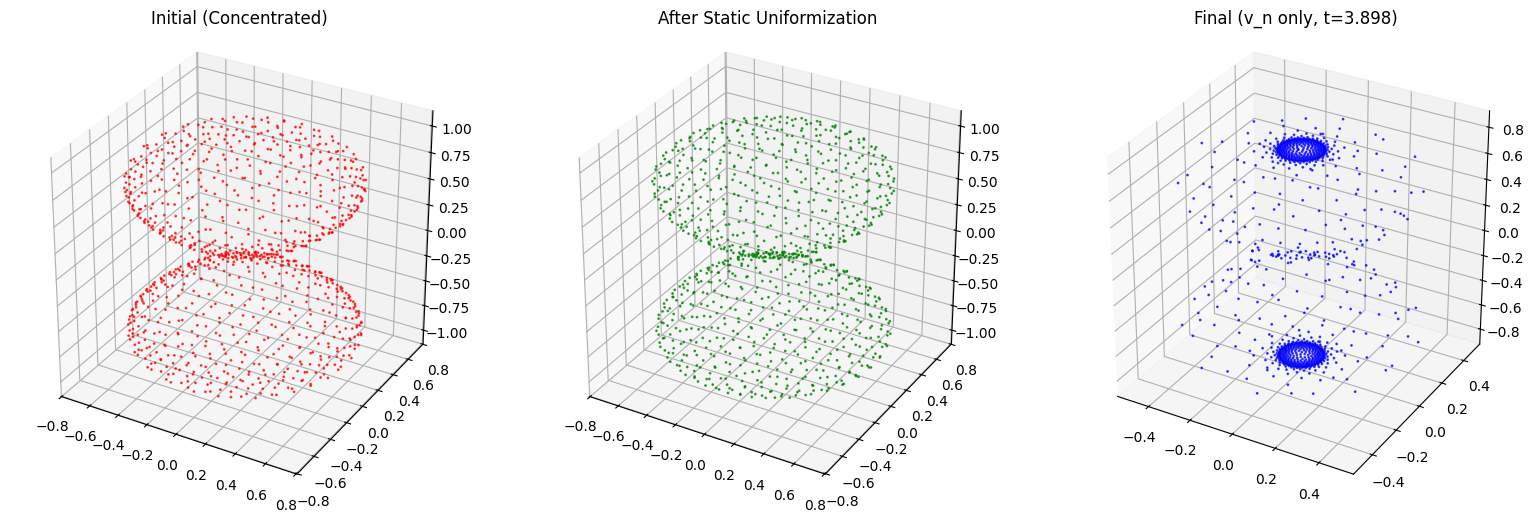

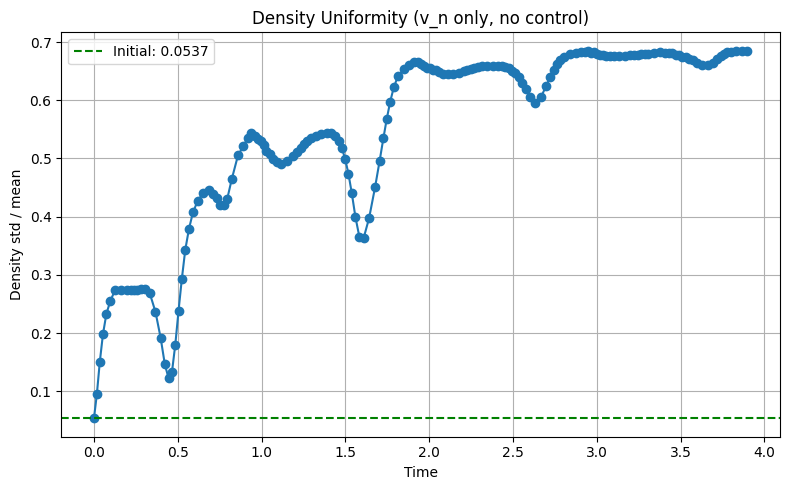


Final density std/mean: 0.685131


In [1]:
# no tagent 1600 steps
import numpy as np
from scipy.linalg import lstsq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================================
# 0. 全局参数
# ============================================================
N = 1000
MAX_DEG_LOCAL = 3      # 阶段1局部基函数中的多项式次数
N_LOCAL = 150
EPSILON = 0.5
MAX_DEG_GLOBAL = 3 
max_deg =3    # 阶段2全局多项式次数
ALPHA = 3.0
DT = 0.01
MAX_STEPS_STATIC = 600
MAX_STEPS_DYNAMIC = 1600
TARGET_STD = 0.005
VELOCITY_TOL = 1e-15
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6

# ============================================================
# 哑铃面参数
# ============================================================
def a_t(t):
    return 0.1 + 0.05 * np.sin(2 * np.pi * t)

def L_t(t):
    return 1.0 + 0.2 * np.sin(4 * np.pi * t)

# ============================================================
# 1. 哑铃面水平集函数
# ============================================================
def level_set(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    s = z**2 / L**2
    G = 200.0 * s * (s - 199.0/200.0)
    return x**2 / a**2 + y**2 / a**2 + G

def level_set_gradient(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    fx = 2.0 * x / a**2
    fy = 2.0 * y / a**2
    s = z**2 / L**2
    dG_ds = 200.0 * (2.0 * s - 199.0/200.0)
    ds_dz = 2.0 * z / L**2
    fz = dG_ds * ds_dz
    return np.column_stack([fx, fy, fz])

def level_set_time_derivative(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    a_dot = 0.05 * 2 * np.pi * np.cos(2 * np.pi * t)
    L_dot = 0.2 * 4 * np.pi * np.cos(4 * np.pi * t)
    s = z**2 / L**2
    dG_ds = 200.0 * (2.0 * s - 199.0/200.0)
    term_a = -2.0 * (x**2 + y**2) / a**3 * a_dot
    term_L = dG_ds * (-2.0 * z**2 / L**3) * L_dot
    return term_a + term_L

# ============================================================
# 2. 投影回曲面
# ============================================================
def project_to_surface(X, t=0.0, max_iter=20):
    for _ in range(max_iter):
        x, y, z = X[:, 0], X[:, 1], X[:, 2]
        f = level_set(x, y, z, t)
        grad_f = level_set_gradient(x, y, z, t)
        grad_norm_sq = np.sum(grad_f**2, axis=1)
        delta = f / (grad_norm_sq + 1e-12)
        X = X - delta[:, None] * grad_f
        if np.max(np.abs(f)) < 1e-12:
            break
    return X

# ============================================================
# 3. 生成点云
# ============================================================
def fibonacci_dumbbell_concentrated(n, concentration=1.0):
    indices = np.arange(n)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n)
    phi_compressed = phi ** concentration * np.pi / (np.pi ** concentration)
    phi_compressed = np.clip(phi_compressed, 0, np.pi)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    
    sx = np.sin(phi_compressed) * np.cos(theta)
    sy = np.sin(phi_compressed) * np.sin(theta)
    sz = np.cos(phi_compressed)
    X = np.column_stack([sx, sy, sz])
    return project_to_surface(X, t=0.0)

# ============================================================
# 4. 法向量
# ============================================================
def estimate_normals(X, t=0.0):
    grad_f = level_set_gradient(X[:, 0], X[:, 1], X[:, 2], t)
    norm = np.linalg.norm(grad_f, axis=1, keepdims=True)
    return grad_f / (norm + 1e-12)

def tangent_projection(v, X, t=0.0):
    normals = estimate_normals(X, t)
    return v - np.sum(v * normals, axis=1, keepdims=True) * normals

# ============================================================
# 5. 多项式基函数
# ============================================================
def polynomial_basis_values(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                vals_list.append((x**i) * (y**j) * (z**k))
    return np.column_stack(vals_list)

def polynomial_basis_gradients(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    N_pts = len(X)
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    grads = np.zeros((N_pts, M_poly, 3))
    col = 0
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                if i > 0:
                    grads[:, col, 0] = i * (x**(i-1)) * (y**j) * (z**k)
                if j > 0:
                    grads[:, col, 1] = j * (x**i) * (y**(j-1)) * (z**k)
                if k > 0:
                    grads[:, col, 2] = k * (x**i) * (y**j) * (z**(k-1))
                col += 1
    return grads

# ============================================================
# 6. 切向梯度
# ============================================================
def tangent_gradients(X, max_deg, t=0.0):
    normals = estimate_normals(X, t)
    grads_3d = polynomial_basis_gradients(X, max_deg)
    normal_proj = np.sum(grads_3d * normals[:, np.newaxis, :], axis=2)
    return grads_3d - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================================
# 7. 局部基函数：Wendland C2（仅阶段1）
# ============================================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    return grad

# ============================================================
# 8. 混合基函数（阶段1）
# ============================================================
def mixed_basis_values(X, max_deg, local_centers, epsilon):
    poly_vals = polynomial_basis_values(X, max_deg)
    local_vals = local_basis_values(X, local_centers, epsilon)
    return np.column_stack([poly_vals, local_vals])

def mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon, t=0.0):
    normals = estimate_normals(X, t)
    poly_grads = polynomial_basis_gradients(X, max_deg)
    local_grads = local_basis_gradients(X, local_centers, epsilon)
    all_grads = np.concatenate([poly_grads, local_grads], axis=1)
    normal_proj = np.sum(all_grads * normals[:, np.newaxis, :], axis=2)
    return all_grads - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================================
# 9. 均匀基函数中心（阶段1）
# ============================================================
def generate_uniform_centers(n_centers, t=0.0):
    indices = np.arange(20000)
    phi = np.arccos(1 - 2 * (indices + 0.5) / 20000)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    sx = np.sin(phi) * np.cos(theta)
    sy = np.sin(phi) * np.sin(theta)
    sz = np.cos(phi)
    X_candidates = np.column_stack([sx, sy, sz])
    X_candidates = project_to_surface(X_candidates, t)
    
    N_pts = len(X_candidates)
    selected_indices = [np.random.randint(N_pts)]
    min_distances = np.full(N_pts, np.inf)
    for _ in range(n_centers - 1):
        last_selected = X_candidates[selected_indices[-1]]
        dist_to_last = np.linalg.norm(X_candidates - last_selected, axis=1)
        min_distances = np.minimum(min_distances, dist_to_last)
        next_idx = np.argmax(min_distances)
        selected_indices.append(next_idx)
        min_distances[next_idx] = -1
    
    return X_candidates[selected_indices].copy()

# ============================================================
# 10. 均匀参考值（加权面积法，阶段1和阶段2统一）
# ============================================================
def compute_uniform_reference_weighted(X_ref, basis_values_func, *args, n_neighbors=20):
    n_samples = len(X_ref)
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, n_neighbors+1)[1:n_neighbors+1]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi_sample = basis_values_func(X_ref, *args)
    return np.average(psi_sample, weights=areas, axis=0)

def generate_uniform_samples(n_samples, t=0.0):
    indices = np.arange(n_samples)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n_samples)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    sx = np.sin(phi) * np.cos(theta)
    sy = np.sin(phi) * np.sin(theta)
    sz = np.cos(phi)
    X = np.column_stack([sx, sy, sz])
    return project_to_surface(X, t)

# ============================================================
# 11. 密度估计
# ============================================================
def estimate_density_std(X, k_neighbors=20):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================================
# 12. 法向速度及散度（阶段2）
# ============================================================
def normal_velocity_from_levelset(X, t):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    ft = level_set_time_derivative(x, y, z, t)
    grad_f = level_set_gradient(x, y, z, t)
    grad_norm = np.linalg.norm(grad_f, axis=1)
    vn_scalar = -ft / (grad_norm + 1e-12)
    normal = grad_f / (grad_norm[:, None] + 1e-12)
    return vn_scalar[:, None] * normal

def normal_velocity_divergence(X, t):
    N_pts = len(X)
    div = np.zeros(N_pts)
    
    grad_f = level_set_gradient(X[:, 0], X[:, 1], X[:, 2], t)
    n_levelset = grad_f / np.linalg.norm(grad_f, axis=1, keepdims=True)
    
    e1 = np.zeros_like(n_levelset)
    mask = np.abs(n_levelset[:, 0]) < 0.9
    e1[mask, 0] = -n_levelset[mask, 1]
    e1[mask, 1] = n_levelset[mask, 0]
    e1[~mask, 1] = -n_levelset[~mask, 2]
    e1[~mask, 2] = n_levelset[~mask, 1]
    e1 = e1 / np.linalg.norm(e1, axis=1, keepdims=True)
    e2 = np.cross(n_levelset, e1)
    
    eps = 1e-5
    for e_vec in [e1, e2]:
        X_plus = X + eps * e_vec
        X_minus = X - eps * e_vec
        vn_plus = normal_velocity_from_levelset(X_plus, t)
        vn_minus = normal_velocity_from_levelset(X_minus, t)
        
        vn_dot_plus = np.sum(vn_plus * e_vec, axis=1)
        vn_dot_minus = np.sum(vn_minus * e_vec, axis=1)
        div += (vn_dot_plus - vn_dot_minus) / (2 * eps)
    
    return div

# ============================================================
# 13. 支撑修剪求解器（阶段1）
# ============================================================
def solve_with_support_pruning(X, max_deg, local_centers, epsilon, b_vector,
                               min_support=5, support_threshold=1e-8, t=0.0):
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_local = len(local_centers)
    M_total = M_poly + M_local
    
    psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
    support_counts = np.sum(np.abs(psi) > support_threshold, axis=0)
    
    poly_valid = np.ones(M_poly, dtype=bool)
    local_valid = support_counts[M_poly:] >= min_support
    valid_mask = np.concatenate([poly_valid, local_valid])
    
    psi_grad_tangent_full = mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon, t)
    psi_grad_valid = psi_grad_tangent_full[:, valid_mask, :]
    
    A_valid = np.mean(psi_grad_valid @ psi_grad_valid.transpose(0, 2, 1), axis=0)
    b_valid = b_vector[valid_mask]
    
    c_valid = np.linalg.solve(A_valid, b_valid)
    
    c = np.zeros(M_total)
    c[valid_mask] = c_valid
    
    vT = np.sum(psi_grad_tangent_full * c[np.newaxis, :, np.newaxis], axis=1)
    vT = tangent_projection(vT, X, t)
    
    return vT, c, valid_mask, support_counts

# ============================================================
# 14. 阶段 1：静曲面均匀化（混合基函数）
# ============================================================
def static_uniformization(X, max_deg, local_centers, epsilon, alpha, target_std, max_steps):
    print("=" * 60)
    print("Stage 1: Static Uniformization (Mixed Basis: Polynomials + Wendland)")
    print("=" * 60)
    
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_total = M_poly + len(local_centers)
    print(f"Polynomial: deg≤{max_deg}, {M_poly} functions")
    print(f"Local: {len(local_centers)} Wendland C2, epsilon={epsilon}")
    print(f"Total: {M_total} basis functions")
    
    # 在 t=0 曲面上生成均匀采样点
    X_ref = generate_uniform_samples(30000, t=0.0)
    uniform_avg = compute_uniform_reference_weighted(
        X_ref, mixed_basis_values, max_deg, local_centers, epsilon
    )
    print("Uniform reference values computed (weighted area method)")
    
    for step in range(max_steps):
        psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
        b_full = -alpha * (np.mean(psi, axis=0) - uniform_avg)
        
        vT, c, valid_mask, support_counts = solve_with_support_pruning(
            X, max_deg, local_centers, epsilon, b_full,
            min_support=MIN_SUPPORT, support_threshold=SUPPORT_THRESHOLD, t=0.0
        )
        
        v_norm = np.max(np.linalg.norm(vT, axis=1))
        if v_norm < VELOCITY_TOL:
            break
        
        dt_effective = min(0.005, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * vT
        X = project_to_surface(X, t=0.0)
        
        if step % 200 == 0:
            density_std = estimate_density_std(X)
            n_active = np.sum(valid_mask)
            residual = np.mean(psi, axis=0) - uniform_avg
            b_max = np.max(np.abs(residual))
            print(f"  Step {step}: density std/mean = {density_std:.6f}, "
                  f"b_max = {b_max:.6e}, active basis = {n_active}/{M_total}, v_max = {v_norm:.4f}")
            
            if density_std < target_std:
                print(f"  Converged at step {step}: density std/mean = {density_std:.6f}")
                break
    
    return X, uniform_avg, M_poly


# ============================================================
# 15. 阶段 2：纯法向速度对照实验
# ============================================================
def dynamic_evolution(X, dt, max_steps, density_check_interval=1):
    """
    纯法向速度对照实验：不加任何切向速度。
    """
    print("=" * 60)
    print("CONTROL: Pure normal velocity (no v_T)")
    print("=" * 60)
    
    density_history = []
    time_history = []
    t_current = 0.0
    
    # 记录初始状态
    density_std = estimate_density_std(X)
    density_history.append(density_std)
    time_history.append(t_current)
    print(f"  Step 0: t = 0.0000, density std/mean = {density_std:.6f}")
    
    for step in range(1, max_steps + 1):
        # 法向速度（只用这个）
        vn = normal_velocity_from_levelset(X, t_current)
        
        v_norm = np.max(np.linalg.norm(vn, axis=1))
        dt_effective = min(dt, 0.005 / (v_norm + 1e-8))
        
        # ====== RK2 中点法 ======
        # 第一阶段：半步
        X_mid = X + 0.5 * dt_effective * vn
        t_mid = t_current + 0.5 * dt_effective
        X_mid = project_to_surface(X_mid, t_mid)
        
        # 第二阶段：用中点速度更新整步
        vn_mid = normal_velocity_from_levelset(X_mid, t_mid)
        
        X = X + dt_effective * vn_mid
        t_current += dt_effective
        X = project_to_surface(X, t_current)
        # ====== RK2 结束 ======
        # 检查终止时间
        if t_current >= 6.23:
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            time_history.append(t_current)
            print(f"  Step {step}: t = {t_current:.4f}, density std/mean = {density_std:.6f}")
            print(f"\n  Reached t = {t_current:.4f} >= 1.23, stopping.")
            break
        # 每 density_check_interval 步估计一次密度
        if step % density_check_interval == 0:
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            time_history.append(t_current)
            print(f"  Step {step}: t = {t_current:.4f}, "
                  f"density std/mean = {density_std:.6f}, v_max = {v_norm:.4f}")
    
    # 最后一步确保记录
    if max_steps % density_check_interval != 0:
        density_std = estimate_density_std(X)
        density_history.append(density_std)
        time_history.append(t_current)
    
    print(f"\nFinal: t = {t_current:.4f}")
    print(f"  Initial density std/mean: {density_history[0]:.6f}")
    print(f"  Final density std/mean:   {density_std:.6f}")
    print(f"  Change: {density_std - density_history[0]:+.6f}")
    # 最终计算 b_residual（纯 v_n 对照）
    X_ref = generate_uniform_samples(20000, t_current)
    uniform_avg_final = compute_uniform_reference_weighted(
        X_ref, polynomial_basis_values, max_deg
    )
    psi_mean_final = np.mean(polynomial_basis_values(X, max_deg), axis=0)
    b_residual_final = np.max(np.abs(psi_mean_final - uniform_avg_final))
    
    print(f"\nFinal: t = {t_current:.4f}")
    print(f"  Initial density std/mean: {density_history[0]:.6f}")
    print(f"  Final density std/mean:   {density_std:.6f}")
    print(f"  Final b_residual_max:     {b_residual_final:.6e}")
    print(f"  Change: {density_std - density_history[0]:+.6f}")
    return X, time_history, density_history


# ============================================================
# 16. 主程序
# ============================================================
def main():
    M_global = polynomial_basis_values(np.zeros((1,3)), MAX_DEG_GLOBAL).shape[1]
    
    print("=" * 60)
    print("Dumbbell Surface: Mixed Basis (Static) -> v_n only (Dynamic Control)")
    print(f"Stage 1: deg≤{MAX_DEG_LOCAL} polynomials + {N_LOCAL} Wendland C2")
    print(f"Stage 2: deg≤{MAX_DEG_GLOBAL}, {M_global} global polynomials (NO v_T)")
    print(f"Particles: {N}")
    print("=" * 60)
    
    X = fibonacci_dumbbell_concentrated(N, concentration=1.0)
    X_initial = X.copy()
    
    print(f"Initial density std/mean: {estimate_density_std(X):.6f}")
    
    np.random.seed(42)
    local_centers = generate_uniform_centers(N_LOCAL, t=0.0)
    print(f"Generated {N_LOCAL} uniform centers for Stage 1")
    
    # 阶段 1
    X_uniform, uniform_avg_mixed, M_poly_stage1 = static_uniformization(
        X, MAX_DEG_LOCAL, local_centers, EPSILON, ALPHA, TARGET_STD, MAX_STEPS_STATIC
    )
    
    # 验证
    print("\n" + "=" * 60)
    print("Verification: Polynomial residual using Stage 1 vs Stage 2 references")
    print("=" * 60)
    
    uniform_avg_poly_from_stage1 = uniform_avg_mixed[:M_poly_stage1]
    psi_poly = polynomial_basis_values(X_uniform, MAX_DEG_GLOBAL)
    residual_using_stage1_ref = np.mean(psi_poly, axis=0) - uniform_avg_poly_from_stage1
    print(f"Using Stage 1 reference: poly residual max = {np.max(np.abs(residual_using_stage1_ref)):.6e}")
    
    X_ref_new = generate_uniform_samples(30000, t=0.0)
    uniform_avg_poly_new = compute_uniform_reference_weighted(
        X_ref_new, polynomial_basis_values, MAX_DEG_GLOBAL
    )
    residual_using_new_ref = np.mean(psi_poly, axis=0) - uniform_avg_poly_new
    print(f"Using new reference:     poly residual max = {np.max(np.abs(residual_using_new_ref)):.6e}")
    
    ref_diff = uniform_avg_poly_from_stage1 - uniform_avg_poly_new
    print(f"Reference difference max: {np.max(np.abs(ref_diff)):.6e}")
    print("=" * 60 + "\n")
    
    # 阶段 2：纯 v_n 对照
    X_final, time_history, density_history = dynamic_evolution(
        X_uniform, DT, MAX_STEPS_DYNAMIC, density_check_interval=10
    )
    
    # ============================================================
    # 可视化
    # ============================================================
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], s=1, c='red', alpha=0.7)
    ax1.set_title('Initial (Concentrated)')
    ax1.set_box_aspect([1, 1, 1])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X_uniform[:, 0], X_uniform[:, 1], X_uniform[:, 2], s=1, c='green', alpha=0.7)
    ax2.set_title('After Static Uniformization')
    ax2.set_box_aspect([1, 1, 1])
    
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(X_final[:, 0], X_final[:, 1], X_final[:, 2], s=1, c='blue', alpha=0.7)
    ax3.set_title(f'Final (v_n only, t={time_history[-1]:.3f})')
    ax3.set_box_aspect([1, 1, 1])
    
    plt.tight_layout()
    plt.show()
    
    # 密度历史图
    if len(density_history) > 1:
        plt.figure(figsize=(8, 5))
        plt.plot(time_history, density_history, 'o-')
        plt.axhline(y=density_history[0], color='g', linestyle='--', 
                     label=f'Initial: {density_history[0]:.4f}')
        plt.xlabel('Time')
        plt.ylabel('Density std / mean')
        plt.title('Density Uniformity (v_n only, no control)')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    print(f"\nFinal density std/mean: {estimate_density_std(X_final):.6f}")
    
    return X_final, time_history, density_history

if __name__ == "__main__":
    X_final, time_history, density_history = main()

Dumbbell Surface: Mixed Basis (Static) -> Global Poly (Dynamic)
Stage 1: deg≤3 polynomials + 150 Wendland C2
Stage 2: deg≤3, 19 global polynomials
Particles: 1000
Initial density std/mean: 0.352132
Generated 150 uniform centers for Stage 1
Stage 1: Static Uniformization (Mixed Basis: Polynomials + Wendland)
Polynomial: deg≤3, 19 functions
Local: 150 Wendland C2, epsilon=0.5
Total: 169 basis functions
Uniform reference values computed (weighted area method)
  Step 0: density std/mean = 0.340025, b_max = 5.108249e-02, active basis = 169/169, v_max = 0.7242
  Step 50: density std/mean = 0.053546, b_max = 5.200624e-05, active basis = 169/169, v_max = 0.0005
  Step 100: density std/mean = 0.053859, b_max = 1.538169e-08, active basis = 169/169, v_max = 0.0000
  Step 150: density std/mean = 0.053859, b_max = 4.548861e-12, active basis = 169/169, v_max = 0.0000

Verification: Polynomial residual using Stage 1 vs Stage 2 references
Using Stage 1 reference: poly residual max = 8.881784e-16
Using

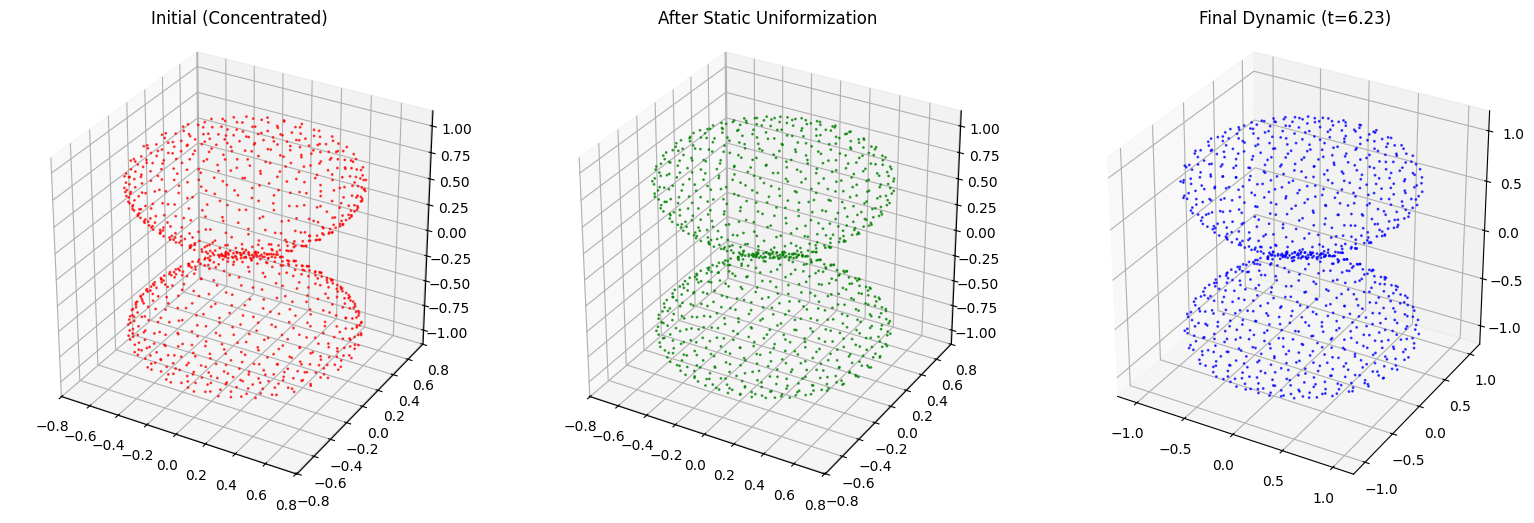

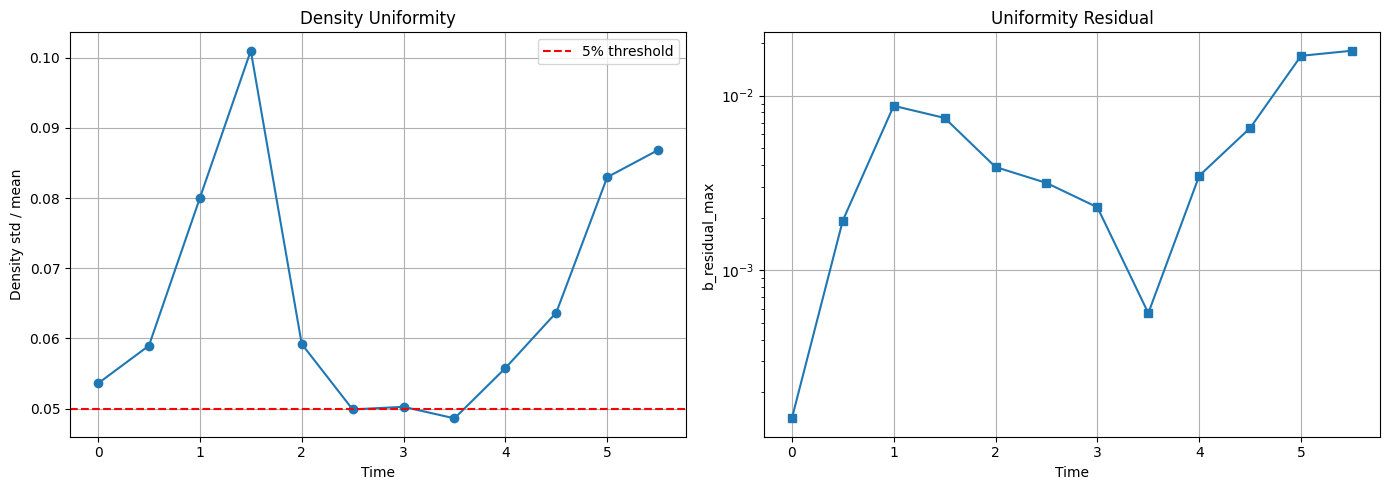


Final density std/mean: 0.086850


In [14]:
import numpy as np
from scipy.linalg import lstsq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================================
# 0. 全局参数
# ============================================================
N = 1000
MAX_DEG_LOCAL = 3      # 阶段1局部基函数中的多项式次数
N_LOCAL = 150
EPSILON = 0.5
MAX_DEG_GLOBAL = 3     # 阶段2全局多项式次数
ALPHA = 3.0
DT = 0.01
MAX_STEPS_STATIC = 200
MAX_STEPS_DYNAMIC = 623
TARGET_STD = 0.01
VELOCITY_TOL = 1e-15
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6

# ============================================================
# 哑铃面参数
# ============================================================
def a_t(t):
    return 0.1 + 0.05 * np.sin(2 * np.pi * t)

def L_t(t):
    return 1.0 + 0.2 * np.sin(4 * np.pi * t)

# ============================================================
# 1. 哑铃面水平集函数
# ============================================================
def level_set(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    s = z**2 / L**2
    G = 200.0 * s * (s - 199.0/200.0)
    return x**2 / a**2 + y**2 / a**2 + G

def level_set_gradient(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    fx = 2.0 * x / a**2
    fy = 2.0 * y / a**2
    s = z**2 / L**2
    dG_ds = 200.0 * (2.0 * s - 199.0/200.0)
    ds_dz = 2.0 * z / L**2
    fz = dG_ds * ds_dz
    return np.column_stack([fx, fy, fz])

def level_set_time_derivative(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    a_dot = 0.05 * 2 * np.pi * np.cos(2 * np.pi * t)
    L_dot = 0.2 * 4 * np.pi * np.cos(4 * np.pi * t)
    s = z**2 / L**2
    dG_ds = 200.0 * (2.0 * s - 199.0/200.0)
    term_a = -2.0 * (x**2 + y**2) / a**3 * a_dot
    term_L = dG_ds * (-2.0 * z**2 / L**3) * L_dot
    return term_a + term_L

# ============================================================
# 2. 投影回曲面
# ============================================================
def project_to_surface(X, t=0.0, max_iter=20):
    for _ in range(max_iter):
        x, y, z = X[:, 0], X[:, 1], X[:, 2]
        f = level_set(x, y, z, t)
        grad_f = level_set_gradient(x, y, z, t)
        grad_norm_sq = np.sum(grad_f**2, axis=1)
        delta = f / (grad_norm_sq + 1e-12)
        X = X - delta[:, None] * grad_f
        if np.max(np.abs(f)) < 1e-12:
            break
    return X

# ============================================================
# 3. 生成点云
# ============================================================
def fibonacci_dumbbell_concentrated(n, concentration=1.0):
    indices = np.arange(n)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n)
    phi_compressed = phi ** concentration * np.pi / (np.pi ** concentration)
    phi_compressed = np.clip(phi_compressed, 0, np.pi)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    
    sx = np.sin(phi_compressed) * np.cos(theta)
    sy = np.sin(phi_compressed) * np.sin(theta)
    sz = np.cos(phi_compressed)
    X = np.column_stack([sx, sy, sz])
    return project_to_surface(X, t=0.0)

# ============================================================
# 4. 法向量
# ============================================================
def estimate_normals(X, t=0.0):
    grad_f = level_set_gradient(X[:, 0], X[:, 1], X[:, 2], t)
    norm = np.linalg.norm(grad_f, axis=1, keepdims=True)
    return grad_f / (norm + 1e-12)

def tangent_projection(v, X, t=0.0):
    normals = estimate_normals(X, t)
    return v - np.sum(v * normals, axis=1, keepdims=True) * normals

# ============================================================
# 5. 多项式基函数
# ============================================================
def polynomial_basis_values(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                vals_list.append((x**i) * (y**j) * (z**k))
    return np.column_stack(vals_list)

def polynomial_basis_gradients(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    N_pts = len(X)
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    grads = np.zeros((N_pts, M_poly, 3))
    col = 0
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                if i > 0:
                    grads[:, col, 0] = i * (x**(i-1)) * (y**j) * (z**k)
                if j > 0:
                    grads[:, col, 1] = j * (x**i) * (y**(j-1)) * (z**k)
                if k > 0:
                    grads[:, col, 2] = k * (x**i) * (y**j) * (z**(k-1))
                col += 1
    return grads

# ============================================================
# 6. 切向梯度
# ============================================================
def tangent_gradients(X, max_deg, t=0.0):
    normals = estimate_normals(X, t)
    grads_3d = polynomial_basis_gradients(X, max_deg)
    normal_proj = np.sum(grads_3d * normals[:, np.newaxis, :], axis=2)
    return grads_3d - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================================
# 7. 局部基函数：Wendland C2（仅阶段1）
# ============================================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    return grad

# ============================================================
# 8. 混合基函数（阶段1）
# ============================================================
def mixed_basis_values(X, max_deg, local_centers, epsilon):
    poly_vals = polynomial_basis_values(X, max_deg)
    local_vals = local_basis_values(X, local_centers, epsilon)
    return np.column_stack([poly_vals, local_vals])

def mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon, t=0.0):
    normals = estimate_normals(X, t)
    poly_grads = polynomial_basis_gradients(X, max_deg)
    local_grads = local_basis_gradients(X, local_centers, epsilon)
    all_grads = np.concatenate([poly_grads, local_grads], axis=1)
    normal_proj = np.sum(all_grads * normals[:, np.newaxis, :], axis=2)
    return all_grads - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================================
# 9. 均匀基函数中心（阶段1）
# ============================================================
def generate_uniform_centers(n_centers, t=0.0):
    indices = np.arange(20000)
    phi = np.arccos(1 - 2 * (indices + 0.5) / 20000)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    sx = np.sin(phi) * np.cos(theta)
    sy = np.sin(phi) * np.sin(theta)
    sz = np.cos(phi)
    X_candidates = np.column_stack([sx, sy, sz])
    X_candidates = project_to_surface(X_candidates, t)
    
    N_pts = len(X_candidates)
    selected_indices = [np.random.randint(N_pts)]
    min_distances = np.full(N_pts, np.inf)
    for _ in range(n_centers - 1):
        last_selected = X_candidates[selected_indices[-1]]
        dist_to_last = np.linalg.norm(X_candidates - last_selected, axis=1)
        min_distances = np.minimum(min_distances, dist_to_last)
        next_idx = np.argmax(min_distances)
        selected_indices.append(next_idx)
        min_distances[next_idx] = -1
    
    return X_candidates[selected_indices].copy()

# ============================================================
# 10. 均匀参考值（加权面积法，阶段1和阶段2统一）
# ============================================================
def compute_uniform_reference_weighted(X_ref, basis_values_func, *args, n_neighbors=20):
    n_samples = len(X_ref)
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, n_neighbors+1)[1:n_neighbors+1]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi_sample = basis_values_func(X_ref, *args)
    return np.average(psi_sample, weights=areas, axis=0)

def generate_uniform_samples(n_samples, t=0.0):
    indices = np.arange(n_samples)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n_samples)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    sx = np.sin(phi) * np.cos(theta)
    sy = np.sin(phi) * np.sin(theta)
    sz = np.cos(phi)
    X = np.column_stack([sx, sy, sz])
    return project_to_surface(X, t)

# ============================================================
# 11. 密度估计
# ============================================================
def estimate_density_std(X, k_neighbors=20):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================================
# 12. 法向速度及散度（阶段2）
# ============================================================
def normal_velocity_from_levelset(X, t):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    ft = level_set_time_derivative(x, y, z, t)
    grad_f = level_set_gradient(x, y, z, t)
    grad_norm = np.linalg.norm(grad_f, axis=1)
    vn_scalar = -ft / (grad_norm + 1e-12)
    normal = grad_f / (grad_norm[:, None] + 1e-12)
    return vn_scalar[:, None] * normal

def normal_velocity_divergence(X, t):
    N_pts = len(X)
    div = np.zeros(N_pts)
    
    grad_f = level_set_gradient(X[:, 0], X[:, 1], X[:, 2], t)
    n_levelset = grad_f / np.linalg.norm(grad_f, axis=1, keepdims=True)
    
    e1 = np.zeros_like(n_levelset)
    mask = np.abs(n_levelset[:, 0]) < 0.9
    e1[mask, 0] = -n_levelset[mask, 1]
    e1[mask, 1] = n_levelset[mask, 0]
    e1[~mask, 1] = -n_levelset[~mask, 2]
    e1[~mask, 2] = n_levelset[~mask, 1]
    e1 = e1 / np.linalg.norm(e1, axis=1, keepdims=True)
    e2 = np.cross(n_levelset, e1)
    
    eps = 1e-5
    for e_vec in [e1, e2]:
        X_plus = X + eps * e_vec
        X_minus = X - eps * e_vec
        vn_plus = normal_velocity_from_levelset(X_plus, t)
        vn_minus = normal_velocity_from_levelset(X_minus, t)
        
        vn_dot_plus = np.sum(vn_plus * e_vec, axis=1)
        vn_dot_minus = np.sum(vn_minus * e_vec, axis=1)
        div += (vn_dot_plus - vn_dot_minus) / (2 * eps)
    
    return div

# ============================================================
# 13. 支撑修剪求解器（阶段1）
# ============================================================
def solve_with_support_pruning(X, max_deg, local_centers, epsilon, b_vector,
                               min_support=5, support_threshold=1e-8, t=0.0):
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_local = len(local_centers)
    M_total = M_poly + M_local
    
    psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
    support_counts = np.sum(np.abs(psi) > support_threshold, axis=0)
    
    poly_valid = np.ones(M_poly, dtype=bool)
    local_valid = support_counts[M_poly:] >= min_support
    valid_mask = np.concatenate([poly_valid, local_valid])
    
    psi_grad_tangent_full = mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon, t)
    psi_grad_valid = psi_grad_tangent_full[:, valid_mask, :]
    
    A_valid = np.mean(psi_grad_valid @ psi_grad_valid.transpose(0, 2, 1), axis=0)
    b_valid = b_vector[valid_mask]
    
    c_valid = np.linalg.solve(A_valid, b_valid)
    
    c = np.zeros(M_total)
    c[valid_mask] = c_valid
    
    vT = np.sum(psi_grad_tangent_full * c[np.newaxis, :, np.newaxis], axis=1)
    vT = tangent_projection(vT, X, t)
    
    return vT, c, valid_mask, support_counts

# ============================================================
# 14. 阶段 1：静曲面均匀化（混合基函数）
# ============================================================
def static_uniformization(X, max_deg, local_centers, epsilon, alpha, target_std, max_steps):
    print("=" * 60)
    print("Stage 1: Static Uniformization (Mixed Basis: Polynomials + Wendland)")
    print("=" * 60)
    
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_total = M_poly + len(local_centers)
    print(f"Polynomial: deg≤{max_deg}, {M_poly} functions")
    print(f"Local: {len(local_centers)} Wendland C2, epsilon={epsilon}")
    print(f"Total: {M_total} basis functions")
    
    X_ref = generate_uniform_samples(30000, t=0.0)
    uniform_avg = compute_uniform_reference_weighted(
        X_ref, mixed_basis_values, max_deg, local_centers, epsilon
    )
    print("Uniform reference values computed (weighted area method)")
    
    for step in range(max_steps):
        psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
        b_full = -alpha * (np.mean(psi, axis=0) - uniform_avg)
        
        vT, c, valid_mask, support_counts = solve_with_support_pruning(
            X, max_deg, local_centers, epsilon, b_full,
            min_support=MIN_SUPPORT, support_threshold=SUPPORT_THRESHOLD, t=0.0
        )
        
        v_norm = np.max(np.linalg.norm(vT, axis=1))
        if v_norm < VELOCITY_TOL:
            break
        
        dt_effective = min(0.05, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * vT
        X = project_to_surface(X, t=0.0)
        
        if step % 50 == 0:
            density_std = estimate_density_std(X)
            n_active = np.sum(valid_mask)
            residual = np.mean(psi, axis=0) - uniform_avg
            b_max = np.max(np.abs(residual))
            print(f"  Step {step}: density std/mean = {density_std:.6f}, "
                  f"b_max = {b_max:.6e}, active basis = {n_active}/{M_total}, v_max = {v_norm:.4f}")
            
            if density_std < target_std:
                print(f"  Converged at step {step}: density std/mean = {density_std:.6f}")
                break
    
    return X, uniform_avg, M_poly
#==============================
# dynamic stage
#===============================
def dynamic_evolution(X, max_deg, dt, max_steps):
    print("=" * 60)
    print("Stage 2: Dynamic Evolution (Global Polynomials)")
    print("=" * 60)
    
    M = polynomial_basis_values(np.zeros((1,3)), max_deg).shape[1]
    print(f"Using {M} global polynomial basis functions (degree 1..{max_deg})")
    
    density_history = []
    residual_history = []
    t_current = 0.0

    for step in range(max_steps):
        vn = normal_velocity_from_levelset(X, t_current)
        div_vn = normal_velocity_divergence(X, t_current)
        
        psi = polynomial_basis_values(X, max_deg)
        grads_tangent = tangent_gradients(X, max_deg, t_current)
        
        A = np.mean(grads_tangent @ grads_tangent.transpose(0, 2, 1), axis=0)
        
        # 驱动项
        f_bar = np.mean(div_vn)
        psi_bar = np.mean(psi, axis=0)
        b_drive = np.zeros(M)
        for m in range(M):
            b_drive[m] = np.mean(psi[:, m] * div_vn) - psi_bar[m] * f_bar
        
        try:
            c = np.linalg.solve(A, b_drive)
        except np.linalg.LinAlgError:
            c = lstsq(A, b_drive)[0]
        
        vT = np.sum(grads_tangent * c[np.newaxis, :, np.newaxis], axis=1)
        vT = tangent_projection(vT, X, t_current)
        
        v_total = vn + vT
        v_norm = np.max(np.linalg.norm(v_total, axis=1))
        dt_effective = min(dt, 0.005 / (v_norm + 1e-8))
        
        # ====== RK2 中点法 ======
        X_mid = X + 0.5 * dt_effective * v_total
        t_mid = t_current + 0.5 * dt_effective
        X_mid = project_to_surface(X_mid, t_mid)
        
        vn_mid = normal_velocity_from_levelset(X_mid, t_mid)
        div_vn_mid = normal_velocity_divergence(X_mid, t_mid)
        
        psi_mid = polynomial_basis_values(X_mid, max_deg)
        grads_tangent_mid = tangent_gradients(X_mid, max_deg, t_mid)
        
        A_mid = np.mean(grads_tangent_mid @ grads_tangent_mid.transpose(0, 2, 1), axis=0)
        
        f_bar_mid = np.mean(div_vn_mid)
        psi_bar_mid = np.mean(psi_mid, axis=0)
        b_drive_mid = np.zeros(M)
        for m in range(M):
            b_drive_mid[m] = np.mean(psi_mid[:, m] * div_vn_mid) - psi_bar_mid[m] * f_bar_mid
        
        try:
            c_mid = np.linalg.solve(A_mid, b_drive_mid)
        except np.linalg.LinAlgError:
            c_mid = lstsq(A_mid, b_drive_mid)[0]
        
        vT_mid = np.sum(grads_tangent_mid * c_mid[np.newaxis, :, np.newaxis], axis=1)
        vT_mid = tangent_projection(vT_mid, X_mid, t_mid)
        
        v_total_mid = vn_mid + vT_mid
        
        X = X + dt_effective * v_total_mid
        t_current += dt_effective
        X = project_to_surface(X, t_current)
        # ====== RK2 结束 ======
        
        # 检查终止时间
        if t_current >= 1.23:
            X_ref = generate_uniform_samples(20000, t_current)
            uniform_avg_current = compute_uniform_reference_weighted(
                X_ref, polynomial_basis_values, max_deg
            )
            psi_mean_current = np.mean(polynomial_basis_values(X, max_deg), axis=0)
            residual = psi_mean_current - uniform_avg_current
            b_max_residual = np.max(np.abs(residual))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            residual_history.append(b_max_residual)
            
            print(f"  Step {step}: t = {t_current:.4f}, density std/mean = {density_std:.6f}, "
                  f"b_drive_max = {np.max(np.abs(b_drive)):.6e}, "
                  f"b_residual_max = {b_max_residual:.6e}, v_max = {v_norm:.4f}")
            print(f"\n  Reached t = {t_current:.4f} >= 1.23, stopping.")
            break
        
        if step % 50 == 0:
            X_ref = generate_uniform_samples(20000, t_current)
            uniform_avg_current = compute_uniform_reference_weighted(
                X_ref, polynomial_basis_values, max_deg
            )
            psi_mean_current = np.mean(polynomial_basis_values(X, max_deg), axis=0)
            residual = psi_mean_current - uniform_avg_current
            b_max_residual = np.max(np.abs(residual))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            residual_history.append(b_max_residual)
            
            print(f"  Step {step}: t = {t_current:.4f}, density std/mean = {density_std:.6f}, "
                  f"b_drive_max = {np.max(np.abs(b_drive)):.6e}, "
                  f"b_residual_max = {b_max_residual:.6e}, v_max = {v_norm:.4f}")
    
    return X, density_history, residual_history
        

# ============================================================
# 16. 主程序
# ============================================================
def main():
    M_global = polynomial_basis_values(np.zeros((1,3)), MAX_DEG_GLOBAL).shape[1]
    
    print("=" * 60)
    print("Dumbbell Surface: Mixed Basis (Static) -> Global Poly (Dynamic)")
    print(f"Stage 1: deg≤{MAX_DEG_LOCAL} polynomials + {N_LOCAL} Wendland C2")
    print(f"Stage 2: deg≤{MAX_DEG_GLOBAL}, {M_global} global polynomials")
    print(f"Particles: {N}")
    print("=" * 60)
    
    X = fibonacci_dumbbell_concentrated(N, concentration=1.0)
    X_initial = X.copy()
    
    print(f"Initial density std/mean: {estimate_density_std(X):.6f}")
    
    np.random.seed(42)
    local_centers = generate_uniform_centers(N_LOCAL, t=0.0)
    print(f"Generated {N_LOCAL} uniform centers for Stage 1")
    
    # 阶段 1
    X_uniform, uniform_avg_mixed, M_poly_stage1 = static_uniformization(
        X, MAX_DEG_LOCAL, local_centers, EPSILON, ALPHA, TARGET_STD, MAX_STEPS_STATIC
    )
    
    # 验证
    print("\n" + "=" * 60)
    print("Verification: Polynomial residual using Stage 1 vs Stage 2 references")
    print("=" * 60)
    
    uniform_avg_poly_from_stage1 = uniform_avg_mixed[:M_poly_stage1]
    psi_poly = polynomial_basis_values(X_uniform, MAX_DEG_GLOBAL)
    residual_using_stage1_ref = np.mean(psi_poly, axis=0) - uniform_avg_poly_from_stage1
    print(f"Using Stage 1 reference: poly residual max = {np.max(np.abs(residual_using_stage1_ref)):.6e}")
    
    X_ref_new = generate_uniform_samples(20000, t=0.0)
    uniform_avg_poly_new = compute_uniform_reference_weighted(
        X_ref_new, polynomial_basis_values, MAX_DEG_GLOBAL
    )
    residual_using_new_ref = np.mean(psi_poly, axis=0) - uniform_avg_poly_new
    print(f"Using new reference:     poly residual max = {np.max(np.abs(residual_using_new_ref)):.6e}")
    
    ref_diff = uniform_avg_poly_from_stage1 - uniform_avg_poly_new
    print(f"Reference difference max: {np.max(np.abs(ref_diff)):.6e}")
    print("=" * 60 + "\n")
    
    # 阶段 2
    X_final, density_history, residual_history = dynamic_evolution(
        X_uniform, MAX_DEG_GLOBAL, DT, MAX_STEPS_DYNAMIC
    )
    
    # ============================================================
    # 可视化
    # ============================================================
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], s=1, c='red', alpha=0.7)
    ax1.set_title('Initial (Concentrated)')
    ax1.set_box_aspect([1, 1, 1])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X_uniform[:, 0], X_uniform[:, 1], X_uniform[:, 2], s=1, c='green', alpha=0.7)
    ax2.set_title('After Static Uniformization')
    ax2.set_box_aspect([1, 1, 1])
    
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(X_final[:, 0], X_final[:, 1], X_final[:, 2], s=1, c='blue', alpha=0.7)
    ax3.set_title(f'Final Dynamic (t={MAX_STEPS_DYNAMIC*DT:.2f})')
    ax3.set_box_aspect([1, 1, 1])
    
    plt.tight_layout()
    plt.show()
    
    if len(density_history) > 0:
        fig2, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 5))
        
        # 用实际步数生成时间轴
        time_axis = np.arange(len(density_history)) * 50 * DT
        
        ax4.plot(time_axis, density_history, 'o-')
        ax4.axhline(y=0.05, color='r', linestyle='--', label='5% threshold')
        ax4.set_xlabel('Time')
        ax4.set_ylabel('Density std / mean')
        ax4.set_title('Density Uniformity')
        ax4.legend()
        ax4.grid(True)
        
        ax5.semilogy(time_axis, residual_history, 's-')
        ax5.set_xlabel('Time')
        ax5.set_ylabel('b_residual_max')
        ax5.set_title('Uniformity Residual')
        ax5.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    print(f"\nFinal density std/mean: {estimate_density_std(X_final):.6f}")
    
    return X_final, density_history, residual_history

if __name__ == "__main__":
    X_final, history, res_history = main()

Dumbbell Surface: Mixed Basis (Static) -> Global Poly (Dynamic)
Stage 1: deg≤3 polynomials + 150 Wendland C2
Stage 2: deg≤3, 19 global polynomials
Particles: 1500
Initial density std/mean: 0.390080
Generated 150 uniform centers for Stage 1
Stage 1: Static Uniformization (Mixed Basis: Polynomials + Wendland)
Polynomial: deg≤3, 19 functions
Local: 150 Wendland C2, epsilon=0.5
Total: 169 basis functions
Uniform reference values computed (weighted area method)
  Step 0: density std/mean = 0.379292, b_max = 5.108246e-02, active basis = 169/169, v_max = 0.7277
  Step 50: density std/mean = 0.049202, b_max = 5.210196e-05, active basis = 169/169, v_max = 0.0005
  Step 100: density std/mean = 0.048688, b_max = 1.541001e-08, active basis = 169/169, v_max = 0.0000
  Step 150: density std/mean = 0.048688, b_max = 4.558298e-12, active basis = 169/169, v_max = 0.0000
  Step 200: density std/mean = 0.048688, b_max = 1.665335e-15, active basis = 169/169, v_max = 0.0000
  Step 250: density std/mean = 0

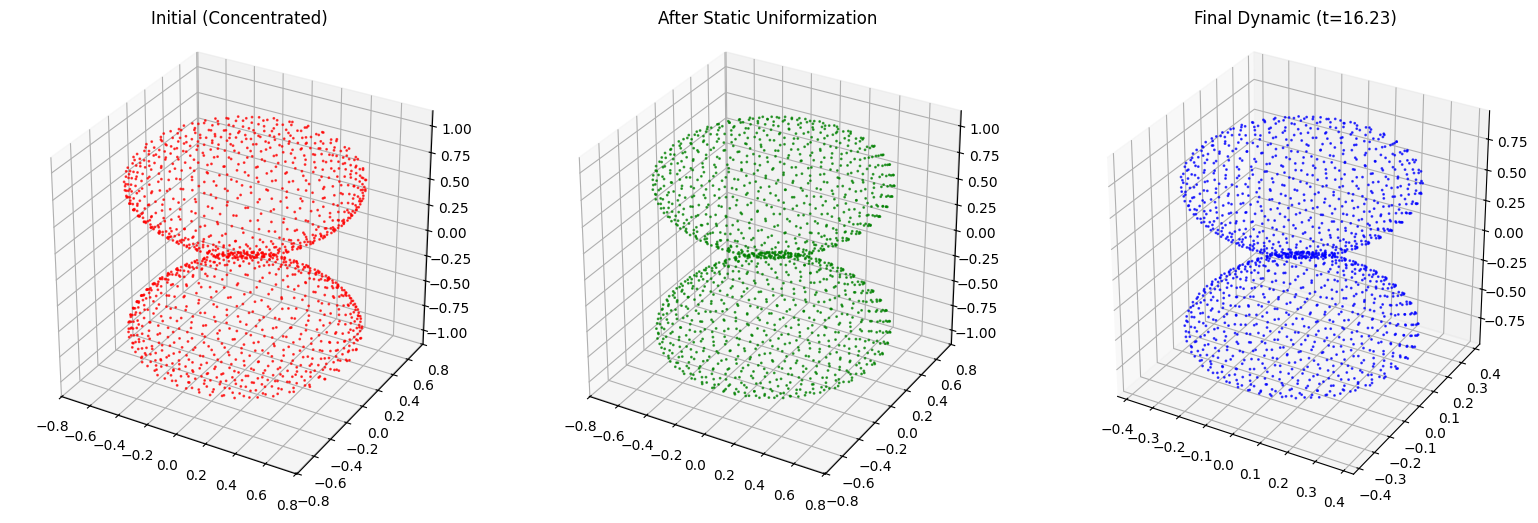

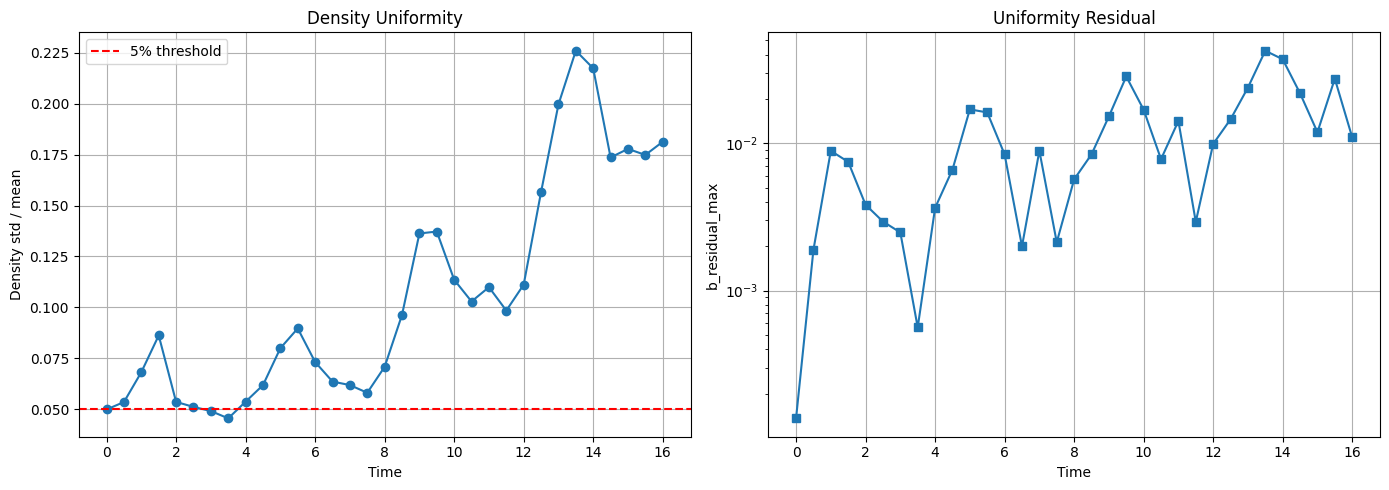


Final density std/mean: 0.209221


In [15]:
import numpy as np
from scipy.linalg import lstsq
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================================
# 0. 全局参数
# ============================================================
N = 1500
MAX_DEG_LOCAL = 3      # 阶段1局部基函数中的多项式次数
N_LOCAL = 150
EPSILON = 0.5
MAX_DEG_GLOBAL = 3     # 阶段2全局多项式次数
ALPHA = 3.0
DT = 0.01
MAX_STEPS_STATIC = 400
MAX_STEPS_DYNAMIC = 1623
TARGET_STD = 0.01
VELOCITY_TOL = 1e-15
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6

# ============================================================
# 哑铃面参数
# ============================================================
def a_t(t):
    return 0.1 + 0.05 * np.sin(2 * np.pi * t)

def L_t(t):
    return 1.0 + 0.2 * np.sin(4 * np.pi * t)

# ============================================================
# 1. 哑铃面水平集函数
# ============================================================
def level_set(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    s = z**2 / L**2
    G = 200.0 * s * (s - 199.0/200.0)
    return x**2 / a**2 + y**2 / a**2 + G

def level_set_gradient(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    fx = 2.0 * x / a**2
    fy = 2.0 * y / a**2
    s = z**2 / L**2
    dG_ds = 200.0 * (2.0 * s - 199.0/200.0)
    ds_dz = 2.0 * z / L**2
    fz = dG_ds * ds_dz
    return np.column_stack([fx, fy, fz])

def level_set_time_derivative(x, y, z, t):
    a = a_t(t)
    L = L_t(t)
    a_dot = 0.05 * 2 * np.pi * np.cos(2 * np.pi * t)
    L_dot = 0.2 * 4 * np.pi * np.cos(4 * np.pi * t)
    s = z**2 / L**2
    dG_ds = 200.0 * (2.0 * s - 199.0/200.0)
    term_a = -2.0 * (x**2 + y**2) / a**3 * a_dot
    term_L = dG_ds * (-2.0 * z**2 / L**3) * L_dot
    return term_a + term_L

# ============================================================
# 2. 投影回曲面
# ============================================================
def project_to_surface(X, t=0.0, max_iter=20):
    for _ in range(max_iter):
        x, y, z = X[:, 0], X[:, 1], X[:, 2]
        f = level_set(x, y, z, t)
        grad_f = level_set_gradient(x, y, z, t)
        grad_norm_sq = np.sum(grad_f**2, axis=1)
        delta = f / (grad_norm_sq + 1e-12)
        X = X - delta[:, None] * grad_f
        if np.max(np.abs(f)) < 1e-12:
            break
    return X

# ============================================================
# 3. 生成点云
# ============================================================
def fibonacci_dumbbell_concentrated(n, concentration=1.0):
    indices = np.arange(n)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n)
    phi_compressed = phi ** concentration * np.pi / (np.pi ** concentration)
    phi_compressed = np.clip(phi_compressed, 0, np.pi)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    
    sx = np.sin(phi_compressed) * np.cos(theta)
    sy = np.sin(phi_compressed) * np.sin(theta)
    sz = np.cos(phi_compressed)
    X = np.column_stack([sx, sy, sz])
    return project_to_surface(X, t=0.0)

# ============================================================
# 4. 法向量
# ============================================================
def estimate_normals(X, t=0.0):
    grad_f = level_set_gradient(X[:, 0], X[:, 1], X[:, 2], t)
    norm = np.linalg.norm(grad_f, axis=1, keepdims=True)
    return grad_f / (norm + 1e-12)

def tangent_projection(v, X, t=0.0):
    normals = estimate_normals(X, t)
    return v - np.sum(v * normals, axis=1, keepdims=True) * normals

# ============================================================
# 5. 多项式基函数
# ============================================================
def polynomial_basis_values(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                vals_list.append((x**i) * (y**j) * (z**k))
    return np.column_stack(vals_list)

def polynomial_basis_gradients(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    N_pts = len(X)
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    grads = np.zeros((N_pts, M_poly, 3))
    col = 0
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                if i > 0:
                    grads[:, col, 0] = i * (x**(i-1)) * (y**j) * (z**k)
                if j > 0:
                    grads[:, col, 1] = j * (x**i) * (y**(j-1)) * (z**k)
                if k > 0:
                    grads[:, col, 2] = k * (x**i) * (y**j) * (z**(k-1))
                col += 1
    return grads

# ============================================================
# 6. 切向梯度
# ============================================================
def tangent_gradients(X, max_deg, t=0.0):
    normals = estimate_normals(X, t)
    grads_3d = polynomial_basis_gradients(X, max_deg)
    normal_proj = np.sum(grads_3d * normals[:, np.newaxis, :], axis=2)
    return grads_3d - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================================
# 7. 局部基函数：Wendland C2（仅阶段1）
# ============================================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    return grad

# ============================================================
# 8. 混合基函数（阶段1）
# ============================================================
def mixed_basis_values(X, max_deg, local_centers, epsilon):
    poly_vals = polynomial_basis_values(X, max_deg)
    local_vals = local_basis_values(X, local_centers, epsilon)
    return np.column_stack([poly_vals, local_vals])

def mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon, t=0.0):
    normals = estimate_normals(X, t)
    poly_grads = polynomial_basis_gradients(X, max_deg)
    local_grads = local_basis_gradients(X, local_centers, epsilon)
    all_grads = np.concatenate([poly_grads, local_grads], axis=1)
    normal_proj = np.sum(all_grads * normals[:, np.newaxis, :], axis=2)
    return all_grads - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================================
# 9. 均匀基函数中心（阶段1）
# ============================================================
def generate_uniform_centers(n_centers, t=0.0):
    indices = np.arange(20000)
    phi = np.arccos(1 - 2 * (indices + 0.5) / 20000)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    sx = np.sin(phi) * np.cos(theta)
    sy = np.sin(phi) * np.sin(theta)
    sz = np.cos(phi)
    X_candidates = np.column_stack([sx, sy, sz])
    X_candidates = project_to_surface(X_candidates, t)
    
    N_pts = len(X_candidates)
    selected_indices = [np.random.randint(N_pts)]
    min_distances = np.full(N_pts, np.inf)
    for _ in range(n_centers - 1):
        last_selected = X_candidates[selected_indices[-1]]
        dist_to_last = np.linalg.norm(X_candidates - last_selected, axis=1)
        min_distances = np.minimum(min_distances, dist_to_last)
        next_idx = np.argmax(min_distances)
        selected_indices.append(next_idx)
        min_distances[next_idx] = -1
    
    return X_candidates[selected_indices].copy()

# ============================================================
# 10. 均匀参考值（加权面积法，阶段1和阶段2统一）
# ============================================================
def compute_uniform_reference_weighted(X_ref, basis_values_func, *args, n_neighbors=20):
    n_samples = len(X_ref)
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, n_neighbors+1)[1:n_neighbors+1]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi_sample = basis_values_func(X_ref, *args)
    return np.average(psi_sample, weights=areas, axis=0)

def generate_uniform_samples(n_samples, t=0.0):
    indices = np.arange(n_samples)
    phi = np.arccos(1 - 2 * (indices + 0.5) / n_samples)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    sx = np.sin(phi) * np.cos(theta)
    sy = np.sin(phi) * np.sin(theta)
    sz = np.cos(phi)
    X = np.column_stack([sx, sy, sz])
    return project_to_surface(X, t)

# ============================================================
# 11. 密度估计
# ============================================================
def estimate_density_std(X, k_neighbors=20):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================================
# 12. 法向速度及散度（阶段2）
# ============================================================
def normal_velocity_from_levelset(X, t):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    ft = level_set_time_derivative(x, y, z, t)
    grad_f = level_set_gradient(x, y, z, t)
    grad_norm = np.linalg.norm(grad_f, axis=1)
    vn_scalar = -ft / (grad_norm + 1e-12)
    normal = grad_f / (grad_norm[:, None] + 1e-12)
    return vn_scalar[:, None] * normal

def normal_velocity_divergence(X, t):
    N_pts = len(X)
    div = np.zeros(N_pts)
    
    grad_f = level_set_gradient(X[:, 0], X[:, 1], X[:, 2], t)
    n_levelset = grad_f / np.linalg.norm(grad_f, axis=1, keepdims=True)
    
    e1 = np.zeros_like(n_levelset)
    mask = np.abs(n_levelset[:, 0]) < 0.9
    e1[mask, 0] = -n_levelset[mask, 1]
    e1[mask, 1] = n_levelset[mask, 0]
    e1[~mask, 1] = -n_levelset[~mask, 2]
    e1[~mask, 2] = n_levelset[~mask, 1]
    e1 = e1 / np.linalg.norm(e1, axis=1, keepdims=True)
    e2 = np.cross(n_levelset, e1)
    
    eps = 1e-5
    for e_vec in [e1, e2]:
        X_plus = X + eps * e_vec
        X_minus = X - eps * e_vec
        vn_plus = normal_velocity_from_levelset(X_plus, t)
        vn_minus = normal_velocity_from_levelset(X_minus, t)
        
        vn_dot_plus = np.sum(vn_plus * e_vec, axis=1)
        vn_dot_minus = np.sum(vn_minus * e_vec, axis=1)
        div += (vn_dot_plus - vn_dot_minus) / (2 * eps)
    
    return div

# ============================================================
# 13. 支撑修剪求解器（阶段1）
# ============================================================
def solve_with_support_pruning(X, max_deg, local_centers, epsilon, b_vector,
                               min_support=5, support_threshold=1e-8, t=0.0):
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_local = len(local_centers)
    M_total = M_poly + M_local
    
    psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
    support_counts = np.sum(np.abs(psi) > support_threshold, axis=0)
    
    poly_valid = np.ones(M_poly, dtype=bool)
    local_valid = support_counts[M_poly:] >= min_support
    valid_mask = np.concatenate([poly_valid, local_valid])
    
    psi_grad_tangent_full = mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon, t)
    psi_grad_valid = psi_grad_tangent_full[:, valid_mask, :]
    
    A_valid = np.mean(psi_grad_valid @ psi_grad_valid.transpose(0, 2, 1), axis=0)
    b_valid = b_vector[valid_mask]
    
    c_valid = np.linalg.solve(A_valid, b_valid)
    
    c = np.zeros(M_total)
    c[valid_mask] = c_valid
    
    vT = np.sum(psi_grad_tangent_full * c[np.newaxis, :, np.newaxis], axis=1)
    vT = tangent_projection(vT, X, t)
    
    return vT, c, valid_mask, support_counts

# ============================================================
# 14. 阶段 1：静曲面均匀化（混合基函数）
# ============================================================
def static_uniformization(X, max_deg, local_centers, epsilon, alpha, target_std, max_steps):
    print("=" * 60)
    print("Stage 1: Static Uniformization (Mixed Basis: Polynomials + Wendland)")
    print("=" * 60)
    
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_total = M_poly + len(local_centers)
    print(f"Polynomial: deg≤{max_deg}, {M_poly} functions")
    print(f"Local: {len(local_centers)} Wendland C2, epsilon={epsilon}")
    print(f"Total: {M_total} basis functions")
    
    X_ref = generate_uniform_samples(30000, t=0.0)
    uniform_avg = compute_uniform_reference_weighted(
        X_ref, mixed_basis_values, max_deg, local_centers, epsilon
    )
    print("Uniform reference values computed (weighted area method)")
    
    for step in range(max_steps):
        psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
        b_full = -alpha * (np.mean(psi, axis=0) - uniform_avg)
        
        vT, c, valid_mask, support_counts = solve_with_support_pruning(
            X, max_deg, local_centers, epsilon, b_full,
            min_support=MIN_SUPPORT, support_threshold=SUPPORT_THRESHOLD, t=0.0
        )
        
        v_norm = np.max(np.linalg.norm(vT, axis=1))
        if v_norm < VELOCITY_TOL:
            break
        
        dt_effective = min(0.05, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * vT
        X = project_to_surface(X, t=0.0)
        
        if step % 50 == 0:
            density_std = estimate_density_std(X)
            n_active = np.sum(valid_mask)
            residual = np.mean(psi, axis=0) - uniform_avg
            b_max = np.max(np.abs(residual))
            print(f"  Step {step}: density std/mean = {density_std:.6f}, "
                  f"b_max = {b_max:.6e}, active basis = {n_active}/{M_total}, v_max = {v_norm:.4f}")
            
            if density_std < target_std:
                print(f"  Converged at step {step}: density std/mean = {density_std:.6f}")
                break
    
    return X, uniform_avg, M_poly
#==============================
# dynamic stage
#===============================
def dynamic_evolution(X, max_deg, dt, max_steps):
    print("=" * 60)
    print("Stage 2: Dynamic Evolution (Global Polynomials)")
    print("=" * 60)
    
    M = polynomial_basis_values(np.zeros((1,3)), max_deg).shape[1]
    print(f"Using {M} global polynomial basis functions (degree 1..{max_deg})")
    
    density_history = []
    residual_history = []
    t_current = 0.0

    for step in range(max_steps):
        vn = normal_velocity_from_levelset(X, t_current)
        div_vn = normal_velocity_divergence(X, t_current)
        
        psi = polynomial_basis_values(X, max_deg)
        grads_tangent = tangent_gradients(X, max_deg, t_current)
        
        A = np.mean(grads_tangent @ grads_tangent.transpose(0, 2, 1), axis=0)
        
        # 驱动项
        f_bar = np.mean(div_vn)
        psi_bar = np.mean(psi, axis=0)
        b_drive = np.zeros(M)
        for m in range(M):
            b_drive[m] = np.mean(psi[:, m] * div_vn) - psi_bar[m] * f_bar
        
        try:
            c = np.linalg.solve(A, b_drive)
        except np.linalg.LinAlgError:
            c = lstsq(A, b_drive)[0]
        
        vT = np.sum(grads_tangent * c[np.newaxis, :, np.newaxis], axis=1)
        vT = tangent_projection(vT, X, t_current)
        
        v_total = vn + vT
        v_norm = np.max(np.linalg.norm(v_total, axis=1))
        dt_effective = min(dt, 0.005 / (v_norm + 1e-8))
        
        # ====== RK2 中点法 ======
        X_mid = X + 0.5 * dt_effective * v_total
        t_mid = t_current + 0.5 * dt_effective
        X_mid = project_to_surface(X_mid, t_mid)
        
        vn_mid = normal_velocity_from_levelset(X_mid, t_mid)
        div_vn_mid = normal_velocity_divergence(X_mid, t_mid)
        
        psi_mid = polynomial_basis_values(X_mid, max_deg)
        grads_tangent_mid = tangent_gradients(X_mid, max_deg, t_mid)
        
        A_mid = np.mean(grads_tangent_mid @ grads_tangent_mid.transpose(0, 2, 1), axis=0)
        
        f_bar_mid = np.mean(div_vn_mid)
        psi_bar_mid = np.mean(psi_mid, axis=0)
        b_drive_mid = np.zeros(M)
        for m in range(M):
            b_drive_mid[m] = np.mean(psi_mid[:, m] * div_vn_mid) - psi_bar_mid[m] * f_bar_mid
        
        try:
            c_mid = np.linalg.solve(A_mid, b_drive_mid)
        except np.linalg.LinAlgError:
            c_mid = lstsq(A_mid, b_drive_mid)[0]
        
        vT_mid = np.sum(grads_tangent_mid * c_mid[np.newaxis, :, np.newaxis], axis=1)
        vT_mid = tangent_projection(vT_mid, X_mid, t_mid)
        
        v_total_mid = vn_mid + vT_mid
        
        X = X + dt_effective * v_total_mid
        t_current += dt_effective
        X = project_to_surface(X, t_current)
        # ====== RK2 结束 ======
        
        # 检查终止时间
        if t_current >= 6.23:
            X_ref = generate_uniform_samples(20000, t_current)
            uniform_avg_current = compute_uniform_reference_weighted(
                X_ref, polynomial_basis_values, max_deg
            )
            psi_mean_current = np.mean(polynomial_basis_values(X, max_deg), axis=0)
            residual = psi_mean_current - uniform_avg_current
            b_max_residual = np.max(np.abs(residual))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            residual_history.append(b_max_residual)
            
            print(f"  Step {step}: t = {t_current:.4f}, density std/mean = {density_std:.6f}, "
                  f"b_drive_max = {np.max(np.abs(b_drive)):.6e}, "
                  f"b_residual_max = {b_max_residual:.6e}, v_max = {v_norm:.4f}")
            print(f"\n  Reached t = {t_current:.4f} >= 1.23, stopping.")
            break
        
        if step % 50 == 0:
            X_ref = generate_uniform_samples(20000, t_current)
            uniform_avg_current = compute_uniform_reference_weighted(
                X_ref, polynomial_basis_values, max_deg
            )
            psi_mean_current = np.mean(polynomial_basis_values(X, max_deg), axis=0)
            residual = psi_mean_current - uniform_avg_current
            b_max_residual = np.max(np.abs(residual))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            residual_history.append(b_max_residual)
            
            print(f"  Step {step}: t = {t_current:.4f}, density std/mean = {density_std:.6f}, "
                  f"b_drive_max = {np.max(np.abs(b_drive)):.6e}, "
                  f"b_residual_max = {b_max_residual:.6e}, v_max = {v_norm:.4f}")
    
    return X, density_history, residual_history
        

# ============================================================
# 16. 主程序
# ============================================================
def main():
    M_global = polynomial_basis_values(np.zeros((1,3)), MAX_DEG_GLOBAL).shape[1]
    
    print("=" * 60)
    print("Dumbbell Surface: Mixed Basis (Static) -> Global Poly (Dynamic)")
    print(f"Stage 1: deg≤{MAX_DEG_LOCAL} polynomials + {N_LOCAL} Wendland C2")
    print(f"Stage 2: deg≤{MAX_DEG_GLOBAL}, {M_global} global polynomials")
    print(f"Particles: {N}")
    print("=" * 60)
    
    X = fibonacci_dumbbell_concentrated(N, concentration=1.0)
    X_initial = X.copy()
    
    print(f"Initial density std/mean: {estimate_density_std(X):.6f}")
    
    np.random.seed(42)
    local_centers = generate_uniform_centers(N_LOCAL, t=0.0)
    print(f"Generated {N_LOCAL} uniform centers for Stage 1")
    
    # 阶段 1
    X_uniform, uniform_avg_mixed, M_poly_stage1 = static_uniformization(
        X, MAX_DEG_LOCAL, local_centers, EPSILON, ALPHA, TARGET_STD, MAX_STEPS_STATIC
    )
    
    # 验证
    print("\n" + "=" * 60)
    print("Verification: Polynomial residual using Stage 1 vs Stage 2 references")
    print("=" * 60)
    
    uniform_avg_poly_from_stage1 = uniform_avg_mixed[:M_poly_stage1]
    psi_poly = polynomial_basis_values(X_uniform, MAX_DEG_GLOBAL)
    residual_using_stage1_ref = np.mean(psi_poly, axis=0) - uniform_avg_poly_from_stage1
    print(f"Using Stage 1 reference: poly residual max = {np.max(np.abs(residual_using_stage1_ref)):.6e}")
    
    X_ref_new = generate_uniform_samples(20000, t=0.0)
    uniform_avg_poly_new = compute_uniform_reference_weighted(
        X_ref_new, polynomial_basis_values, MAX_DEG_GLOBAL
    )
    residual_using_new_ref = np.mean(psi_poly, axis=0) - uniform_avg_poly_new
    print(f"Using new reference:     poly residual max = {np.max(np.abs(residual_using_new_ref)):.6e}")
    
    ref_diff = uniform_avg_poly_from_stage1 - uniform_avg_poly_new
    print(f"Reference difference max: {np.max(np.abs(ref_diff)):.6e}")
    print("=" * 60 + "\n")
    
    # 阶段 2
    X_final, density_history, residual_history = dynamic_evolution(
        X_uniform, MAX_DEG_GLOBAL, DT, MAX_STEPS_DYNAMIC
    )
    
    # ============================================================
    # 可视化
    # ============================================================
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], s=1, c='red', alpha=0.7)
    ax1.set_title('Initial (Concentrated)')
    ax1.set_box_aspect([1, 1, 1])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X_uniform[:, 0], X_uniform[:, 1], X_uniform[:, 2], s=1, c='green', alpha=0.7)
    ax2.set_title('After Static Uniformization')
    ax2.set_box_aspect([1, 1, 1])
    
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(X_final[:, 0], X_final[:, 1], X_final[:, 2], s=1, c='blue', alpha=0.7)
    ax3.set_title(f'Final Dynamic (t={MAX_STEPS_DYNAMIC*DT:.2f})')
    ax3.set_box_aspect([1, 1, 1])
    
    plt.tight_layout()
    plt.show()
    
    if len(density_history) > 0:
        fig2, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 5))
        
        # 用实际步数生成时间轴
        time_axis = np.arange(len(density_history)) * 50 * DT
        
        ax4.plot(time_axis, density_history, 'o-')
        ax4.axhline(y=0.05, color='r', linestyle='--', label='5% threshold')
        ax4.set_xlabel('Time')
        ax4.set_ylabel('Density std / mean')
        ax4.set_title('Density Uniformity')
        ax4.legend()
        ax4.grid(True)
        
        ax5.semilogy(time_axis, residual_history, 's-')
        ax5.set_xlabel('Time')
        ax5.set_ylabel('b_residual_max')
        ax5.set_title('Uniformity Residual')
        ax5.grid(True)
        
        plt.tight_layout()
        plt.show()
    
    print(f"\nFinal density std/mean: {estimate_density_std(X_final):.6f}")
    
    return X_final, density_history, residual_history

if __name__ == "__main__":
    X_final, history, res_history = main()